## Imports
Import necessary libraries for data analysis and visualization.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Exploration
Explore the dataset structure and verify:
- Player and gameweek data formats are consistent
- Differences and compatibility between seasons

In [29]:
# take the season 2017/18 as an example
data_gameweek_5_2017_18 = pd.read_csv('data/2017-18/gws/gw5.csv', encoding='latin-1')
data_players_mahrez_2017_18 = pd.read_csv('data/2017-18/players/Riyad_Mahrez/gw.csv', encoding='latin-1')

### Compare Dataset Samples
Examine samples from both dataset formats to determine which to use for analysis.

In [30]:
print(data_gameweek_5_2017_18.shape)
print(data_players_mahrez_2017_18.shape)

(546, 55)
(38, 54)


In [31]:
data_players_mahrez_2017_18.head()

,assists,attempted_passes,big_chances_created,big_chances_missed,bonus,bps,clean_sheets,clearances_blocks_interceptions,completed_passes,creativity,...,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,winning_goals,yellow_cards
0,1,30,0,0,0,10,0,1,23,23.4,...,4,7.0,5,0,0,0,85,False,0,0
1,2,41,0,0,2,34,1,2,36,29.6,...,2,56.0,11,24327,33182,8855,85,True,0,0
2,0,37,0,0,0,13,0,0,29,2.1,...,2,51.0,2,32593,55870,23277,85,False,0,0
3,0,28,1,0,0,8,0,0,23,26.8,...,1,2.0,2,-2535,30618,33153,85,True,0,0
4,0,34,0,0,0,9,0,2,27,29.0,...,1,46.0,2,20900,46130,25230,85,False,0,0


In [32]:
data_gameweek_5_2017_18.head()

,name,assists,attempted_passes,big_chances_created,big_chances_missed,bonus,bps,clean_sheets,clearances_blocks_interceptions,completed_passes,...,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,winning_goals,yellow_cards
0,Aaron_Cresswell,0,30,0,0,3,30,1,4,27,...,0,0.0,9,905,3136,2231,50,False,0,0
1,Aaron_Lennon,0,0,0,0,0,0,0,0,0,...,4,0.0,0,-303,157,460,55,False,0,0
2,Aaron_Mooy,0,84,0,0,0,20,0,2,69,...,1,8.0,2,1799,54461,52662,57,True,0,0
3,Aaron_Ramsey,0,51,0,0,0,18,1,5,42,...,0,14.0,3,933,15672,14739,70,False,0,0
4,Abdelhamid_Sabiri,1,38,0,0,0,19,0,3,27,...,1,20.0,5,22,49,27,50,True,0,0


In [33]:
player_columns = data_players_mahrez_2017_18.columns.tolist()
gw_columns = data_gameweek_5_2017_18.columns.tolist()
print("Player Data Columns:", player_columns)
print("Gameweek Data Columns:", gw_columns)
# print the columns that are in the intersection of both datasets
common_columns = set(player_columns).intersection(set(gw_columns))
print("Common Columns:", sorted(common_columns))
# the columns that exist in gw but not in player data
gw_only_columns = set(gw_columns) - set(player_columns)
print("GW Only Columns:", sorted(gw_only_columns))
# the columns that exist in player data but not in gw
player_only_columns = set(player_columns) - set(gw_columns)
print("Player Only Columns:", sorted(player_only_columns))

Player Data Columns: ['assists', 'attempted_passes', 'big_chances_created', 'big_chances_missed', 'bonus', 'bps', 'clean_sheets', 'clearances_blocks_interceptions', 'completed_passes', 'creativity', 'dribbles', 'ea_index', 'element', 'errors_leading_to_goal', 'errors_leading_to_goal_attempt', 'fixture', 'fouls', 'goals_conceded', 'goals_scored', 'ict_index', 'id', 'influence', 'key_passes', 'kickoff_time', 'kickoff_time_formatted', 'loaned_in', 'loaned_out', 'minutes', 'offside', 'open_play_crosses', 'opponent_team', 'own_goals', 'penalties_conceded', 'penalties_missed', 'penalties_saved', 'recoveries', 'red_cards', 'round', 'saves', 'selected', 'tackled', 'tackles', 'target_missed', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'winning_goals', 'yellow_cards']
Gameweek Data Columns: ['name', 'assists', 'attempted_passes', 'big_chances_created', 'big_chances_missed', 'bonus', 'bps', 'clean_sheets', '

### Dataset Comparison Results
**Key findings:**
- Both formats contain the same data, but gameweek files include player names

- The `round` attribute corresponds to the gameweek number- **Decision:** Use gameweek (GW) data as it's more convenient for analysis

In [34]:
# I see that there is also two important tables in the dataset: merged_gw.csv and cleaned_players.csv. I will load and explore them next.
data_merged_gw_2017_18 = pd.read_csv('data/2017-18/gws/merged_gw.csv', encoding='latin-1')
data_cleaned_players_2017_18 = pd.read_csv('data/2017-18/cleaned_players.csv', encoding='latin-1')
print(data_merged_gw_2017_18.shape)
print(data_cleaned_players_2017_18.shape)

(22467, 56)
(647, 18)


In [35]:
data_merged_gw_2017_18.head()

,name,assists,attempted_passes,big_chances_created,big_chances_missed,bonus,bps,clean_sheets,clearances_blocks_interceptions,completed_passes,...,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,winning_goals,yellow_cards,GW
0,Aaron_Cresswell,0,10,0,0,0,3,0,0,9,...,18,0,0,0,0,50,False,0,0,1
1,Aaron_Lennon,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,55,True,0,0,1
2,Aaron_Mooy,1,52,0,0,0,22,1,5,41,...,0,6,0,0,0,55,False,0,0,1
3,Aaron_Ramsey,0,11,0,1,0,16,0,0,8,...,26,6,0,0,0,70,True,0,0,1
4,Abdoulaye_Doucouré,0,73,0,0,2,36,0,3,60,...,35,9,0,0,0,50,True,0,0,1


In [36]:
data_cleaned_players_2017_18.head()

,first_name,second_name,goals_scored,assists,total_points,minutes,goals_conceded,creativity,influence,threat,bonus,bps,ict_index,clean_sheets,red_cards,yellow_cards,selected_by_percent,now_cost
0,David,Ospina,0,0,19,380,3,0.0,75.8,0.0,1,86,7.7,2,0,0,0.2,48
1,Petr,Cech,0,0,124,3039,48,0.0,722.4,0.0,7,627,71.9,11,0,1,4.5,53
2,Damian Emiliano,Martinez,0,0,0,0,0,0.0,0.0,0.0,0,0,0.0,0,0,0,0.6,40
3,Laurent,Koscielny,2,0,100,2225,32,123.8,692.0,137.0,16,556,95.5,9,0,4,1.5,60
4,Per,Mertesacker,1,0,16,364,7,3.0,119.6,38.0,2,81,16.1,0,0,0,0.5,47


In [37]:
# print the columns of both of them, the intersection, and the unique columns
merged_gw_columns = data_merged_gw_2017_18.columns.tolist()
cleaned_players_columns = data_cleaned_players_2017_18.columns.tolist()
print("Merged GW Data Columns:", sorted(merged_gw_columns))
print("Cleaned Players Data Columns:", sorted(cleaned_players_columns))
common_merged_cleaned_columns = set(merged_gw_columns).intersection(set(cleaned_players_columns))
print("Common Columns:", sorted(common_merged_cleaned_columns))
# the columns that exist in merged gw but not in cleaned players
merged_only_columns = set(merged_gw_columns) - set(cleaned_players_columns)
print("Merged Only Columns:", sorted(merged_only_columns))
# the columns that exist in cleaned players but not in merged gw
cleaned_only_columns = set(cleaned_players_columns) - set(merged_gw_columns)
print("Cleaned Only Columns:", sorted(cleaned_only_columns))

Merged GW Data Columns: ['GW', 'assists', 'attempted_passes', 'big_chances_created', 'big_chances_missed', 'bonus', 'bps', 'clean_sheets', 'clearances_blocks_interceptions', 'completed_passes', 'creativity', 'dribbles', 'ea_index', 'element', 'errors_leading_to_goal', 'errors_leading_to_goal_attempt', 'fixture', 'fouls', 'goals_conceded', 'goals_scored', 'ict_index', 'id', 'influence', 'key_passes', 'kickoff_time', 'kickoff_time_formatted', 'loaned_in', 'loaned_out', 'minutes', 'name', 'offside', 'open_play_crosses', 'opponent_team', 'own_goals', 'penalties_conceded', 'penalties_missed', 'penalties_saved', 'recoveries', 'red_cards', 'round', 'saves', 'selected', 'tackled', 'tackles', 'target_missed', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'winning_goals', 'yellow_cards']
Cleaned Players Data Columns: ['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'first_name', 'goals_conceded', 'goa

### Cleaned Players Data
The `cleaned_players.csv` contains aggregated season-level stats, which is not suitable for our gameweek-level analysis.

In [38]:
# compare the dataset of one gameweek with the merged gw dataset
print("Merged GW Data Columns:", sorted(merged_gw_columns))
print("GW Data Columns:", sorted(gw_columns))
common_merged_gw_columns = set(merged_gw_columns).intersection(set(gw_columns))
print("Common Columns:", sorted(common_merged_gw_columns))
# the columns that exist in merged gw but not in gw
merged_gw_only_columns = set(merged_gw_columns) - set(gw_columns)
print("Merged GW Only Columns:", sorted(merged_gw_only_columns))
# the columns that exist in gw but not in merged gw
gw_merged_only_columns = set(gw_columns) - set(merged_gw_columns)
print("GW Merged Only Columns:", sorted(gw_merged_only_columns))


Merged GW Data Columns: ['GW', 'assists', 'attempted_passes', 'big_chances_created', 'big_chances_missed', 'bonus', 'bps', 'clean_sheets', 'clearances_blocks_interceptions', 'completed_passes', 'creativity', 'dribbles', 'ea_index', 'element', 'errors_leading_to_goal', 'errors_leading_to_goal_attempt', 'fixture', 'fouls', 'goals_conceded', 'goals_scored', 'ict_index', 'id', 'influence', 'key_passes', 'kickoff_time', 'kickoff_time_formatted', 'loaned_in', 'loaned_out', 'minutes', 'name', 'offside', 'open_play_crosses', 'opponent_team', 'own_goals', 'penalties_conceded', 'penalties_missed', 'penalties_saved', 'recoveries', 'red_cards', 'round', 'saves', 'selected', 'tackled', 'tackles', 'target_missed', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'winning_goals', 'yellow_cards']
GW Data Columns: ['assists', 'attempted_passes', 'big_chances_created', 'big_chances_missed', 'bonus', 'bps', 'clean_sheets'

In [39]:
# Verify that merged_gw.csv contains all gameweek data with GW numbers
# Check the number of unique gameweeks
# Verify that the GW column matches the round column
unique_gameweeks = data_merged_gw_2017_18['GW'].nunique()
print("Number of unique gameweeks in merged dataset:", unique_gameweeks)
# check if gw column is the same as round column
gw_round_comparison = data_merged_gw_2017_18[['GW', 'round']].drop_duplicates()
print(gw_round_comparison)

Number of unique gameweeks in merged dataset: 38
       GW  round
0       1      1
511    10     10
1074   11     11
1640   12     12
2209   13     13
2779   14     14
3350   15     15
3924   16     16
4501   17     17
5079   18     18
5659   19     19
6244    2      2
6760   20     20
7346   21     21
7872   22     22
8523   23     23
9121   24     24
9724   25     25
10337  26     26
10962  27     27
11589  28     28
12219  29     29
12852   3      3
13383  30     30
14017  31     31
14284  32     32
14921  33     33
15562  34     34
16439  35     35
16846  36     36
17490  37     37
18510  38     38
19157   4      4
19701   5      5
20247   6      6
20797   7      7
21351   8      8
21908   9      9


## Data Preparation Strategy
The merged gameweek data is ready to use. Next steps:
1. Verify differences across seasons

2. Add season identifiers3. Merge all seasons into a single dataset

In [40]:
# first read the merged data of each season and compare them to see if they have the same structure
data_merged_gw_2016_17 = pd.read_csv('data/2016-17/gws/merged_gw.csv', encoding='latin-1', on_bad_lines='skip')
data_merged_gw_2017_18 = pd.read_csv('data/2017-18/gws/merged_gw.csv', encoding='latin-1', on_bad_lines='skip')
data_merged_gw_2018_19 = pd.read_csv('data/2018-19/gws/merged_gw.csv', encoding='latin-1', on_bad_lines='skip')
data_merged_gw_2019_20 = pd.read_csv('data/2019-20/gws/merged_gw.csv', encoding='latin-1', on_bad_lines='skip')
data_merged_gw_2020_21 = pd.read_csv('data/2020-21/gws/merged_gw.csv', encoding='latin-1', on_bad_lines='skip')
data_merged_gw_2021_22 = pd.read_csv('data/2021-22/gws/merged_gw.csv', encoding='latin-1', on_bad_lines='skip')
data_merged_gw_2022_23 = pd.read_csv('data/2022-23/gws/merged_gw.csv', encoding='latin-1', on_bad_lines='skip')
data_merged_gw_2023_24 = pd.read_csv('data/2023-24/gws/merged_gw.csv', encoding='latin-1', on_bad_lines='skip')
data_merged_gw_2024_25 = pd.read_csv('data/2024-25/gws/merged_gw.csv', encoding='latin-1', on_bad_lines='skip')
data_merged_gw_2025_26 = pd.read_csv('data/2025-26/gws/merged_gw.csv', encoding='latin-1', on_bad_lines='skip')
print("2016-17 Merged GW Shape:", data_merged_gw_2016_17.shape)
print("2017-18 Merged GW Shape:", data_merged_gw_2017_18.shape)
print("2018-19 Merged GW Shape:", data_merged_gw_2018_19.shape)
print("2019-20 Merged GW Shape:", data_merged_gw_2019_20.shape)
print("2020-21 Merged GW Shape:", data_merged_gw_2020_21.shape)
print("2021-22 Merged GW Shape:", data_merged_gw_2021_22.shape)
print("2022-23 Merged GW Shape:", data_merged_gw_2022_23.shape)
print("2023-24 Merged GW Shape:", data_merged_gw_2023_24.shape)
print("2024-25 Merged GW Shape:", data_merged_gw_2024_25.shape)
print("2025-26 Merged GW Shape:", data_merged_gw_2025_26.shape)
# compare the columns of all these datasets
merged_2016_17_columns = set(data_merged_gw_2016_17.columns.tolist())
merged_2017_18_columns = set(data_merged_gw_2017_18.columns.tolist())
merged_2018_19_columns = set(data_merged_gw_2018_19.columns.tolist())
merged_2019_20_columns = set(data_merged_gw_2019_20.columns.tolist())
merged_2020_21_columns = set(data_merged_gw_2020_21.columns.tolist())
merged_2021_22_columns = set(data_merged_gw_2021_22.columns.tolist())
merged_2022_23_columns = set(data_merged_gw_2022_23.columns.tolist())
merged_2023_24_columns = set(data_merged_gw_2023_24.columns.tolist())
merged_2024_25_columns = set(data_merged_gw_2024_25.columns.tolist())
merged_2025_26_columns = set(data_merged_gw_2025_26.columns.tolist())
# find the common columns across all seasons
common_merged_columns_all_seasons = merged_2016_17_columns.intersection(merged_2017_18_columns).intersection(merged_2018_19_columns).intersection(merged_2019_20_columns).intersection(merged_2020_21_columns).intersection(merged_2021_22_columns).intersection(merged_2022_23_columns).intersection(merged_2023_24_columns).intersection(merged_2024_25_columns).intersection(merged_2025_26_columns)
print("Common Columns Across All Seasons:", sorted(common_merged_columns_all_seasons))
# find the unique columns in each season compared to the common columns
unique_2016_17_columns = merged_2016_17_columns - common_merged_columns_all_seasons
unique_2017_18_columns = merged_2017_18_columns - common_merged_columns_all_seasons
unique_2018_19_columns = merged_2018_19_columns - common_merged_columns_all_seasons
unique_2019_20_columns = merged_2019_20_columns - common_merged_columns_all_seasons
unique_2020_21_columns = merged_2020_21_columns - common_merged_columns_all_seasons
unique_2021_22_columns = merged_2021_22_columns - common_merged_columns_all_seasons
unique_2022_23_columns = merged_2022_23_columns - common_merged_columns_all_seasons
unique_2023_24_columns = merged_2023_24_columns - common_merged_columns_all_seasons
unique_2024_25_columns = merged_2024_25_columns - common_merged_columns_all_seasons
unique_2025_26_columns = merged_2025_26_columns - common_merged_columns_all_seasons
print("Unique Columns in 2016-17:", sorted(unique_2016_17_columns))
print("Unique Columns in 2017-18:", sorted(unique_2017_18_columns))
print("Unique Columns in 2018-19:", sorted(unique_2018_19_columns))
print("Unique Columns in 2019-20:", sorted(unique_2019_20_columns))
print("Unique Columns in 2020-21:", sorted(unique_2020_21_columns))
print("Unique Columns in 2021-22:", sorted(unique_2021_22_columns))
print("Unique Columns in 2022-23:", sorted(unique_2022_23_columns))
print("Unique Columns in 2023-24:", sorted(unique_2023_24_columns))
print("Unique Columns in 2024-25:", sorted(unique_2024_25_columns))
print("Unique Columns in 2025-26:", sorted(unique_2025_26_columns))


2016-17 Merged GW Shape: (23679, 56)
2017-18 Merged GW Shape: (22467, 56)
2018-19 Merged GW Shape: (21790, 56)
2019-20 Merged GW Shape: (22560, 33)
2020-21 Merged GW Shape: (24365, 36)
2021-22 Merged GW Shape: (25447, 36)
2022-23 Merged GW Shape: (26505, 41)
2023-24 Merged GW Shape: (29725, 41)
2024-25 Merged GW Shape: (14178, 42)
2025-26 Merged GW Shape: (5821, 46)
Common Columns Across All Seasons: ['GW', 'assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'name', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards']
Unique Columns in 2016-17: ['attempted_passes', 'big_chances_created', 'big_chances_missed', 'clearances_blocks_interceptions', 'completed_passes', 'dribb

## Column Analysis Across Seasons
Identify common and unique columns across all seasons to ensure data compatibility.

## Data Challenges and Solutions
**Issues to address:**
- Position data missing before 2020 → Extract from player raw files
- Team names need to be added for older seasons
- New metrics (defensive contributions) only in recent seasons

- Expected goals/assists handling → Drop for consistency**Note:** Focus on recent seasons as football dynamics have changed significantly.

- EA index → Drop, use ICT index instead

In [41]:
# Add position column to merged gameweek data based on element_type from player raw data
def add_position_to_merged_gw(merged_gw_df, cleaned_players_df):
    # Map element_type to position names
    element_type_to_position = {
        1: 'Goalkeeper',
        2: 'Defender',
        3: 'Midfielder',
        4: 'Forward'
    }
    # create a new column 'position' in cleaned players dataframe
    cleaned_players_df['position'] = cleaned_players_df['element_type'].map(element_type_to_position)
    # create a mapping from player id to position
    player_id_to_position = dict(zip(cleaned_players_df['id'], cleaned_players_df['position']))
    # add the position column to the merged gw dataframe
    merged_gw_df['position'] = merged_gw_df['element'].map(player_id_to_position)
    return merged_gw_df


In [42]:
# first load the raw player data for each season until 2019-20
data_players_2016_17 = pd.read_csv('data/2016-17/players_raw.csv', encoding='latin-1', on_bad_lines='skip')
data_players_2017_18 = pd.read_csv('data/2017-18/players_raw.csv', encoding='latin-1', on_bad_lines='skip')
data_players_2018_19 = pd.read_csv('data/2018-19/players_raw.csv', encoding='latin-1', on_bad_lines='skip')
data_players_2019_20 = pd.read_csv('data/2019-20/players_raw.csv', encoding='latin-1', on_bad_lines='skip')

In [43]:
# add the position column to each season's player data
data_merged_gw_2016_17 = add_position_to_merged_gw(data_merged_gw_2016_17, data_players_2016_17)
data_merged_gw_2017_18 = add_position_to_merged_gw(data_merged_gw_2017_18, data_players_2017_18)
data_merged_gw_2018_19 = add_position_to_merged_gw(data_merged_gw_2018_19, data_players_2018_19)
data_merged_gw_2019_20 = add_position_to_merged_gw(data_merged_gw_2019_20, data_players_2019_20)

In [44]:
# print random samples from each season's player data to verify the position column
print(data_merged_gw_2016_17[['element', 'name',  'position']].sample(5))
print(data_merged_gw_2017_18[['element', 'name', 'position']].sample(5))
print(data_merged_gw_2018_19[['element', 'name', 'position']].sample(5))
print(data_merged_gw_2019_20[['element', 'name', 'position']].sample(5))

       element                    name    position
12487      285              Adam_Reach  Midfielder
17015      523  Trent_Alexander-Arnold  Midfielder
23021      551          Sofiane_Boufal  Midfielder
5885       484             Rob_Holding    Defender
18374      239           Sergio_Agüero     Forward
       element               name    position
9633       445          Sam_Byram    Defender
21219       75      Paul_Robinson  Goalkeeper
5467        44         Max_Gradel  Midfielder
9251       236   Daniel_Sturridge     Forward
12341      396  Costel_Pantilimon  Goalkeeper
       element                   name    position
12421      236  Kelechi_Iheanacho_236     Forward
4680       339  Oriol_Romeu Vidal_339  Midfielder
202        368        Harry_Winks_368  Midfielder
14809      584        Lucas_Perri_584  Goalkeeper
14200      243         Joel_Matip_243    Defender
       element                                  name    position
8630       133                     Wilfried_Zaha_133 

In [45]:
# I will verify that the element column is the same as the id column in the datamerged gw datasets
print(data_merged_gw_2016_17[['element', 'id']].drop_duplicates().shape)
print(data_merged_gw_2017_18[['element', 'id']].drop_duplicates().shape)
print(data_merged_gw_2018_19[['element', 'id']].drop_duplicates().shape)

(23679, 2)
(22467, 2)
(21790, 2)


### Player Element ID
The `element` column represents the unique player ID for each season (resets each year).

In [46]:
# Add team names to seasons 2016-17 through 2019-20 using master team list
# Process:
# 1. Load master team list (contains season → team_id → team_name mapping)
# 2. Map player_id → team_id from player raw data
# 3. Map team_id → team_name from master list
# 4. Add team_name column to merged GW data
data_master_team_list = pd.read_csv('data/master_team_list.csv', encoding='latin-1', on_bad_lines='skip')
def add_team_name_to_merged_gw(merged_gw_df, players_raw_df, master_team_list_df, season):
    # filter the master team list for the given season
    season_team_list = master_team_list_df[master_team_list_df['season'] == season]
    # create a mapping from team id to team name
    team_id_to_name = dict(zip(season_team_list['team'], season_team_list['team_name']))
    # create a mapping from player id to team id
    player_id_to_team_id = dict(zip(players_raw_df['id'], players_raw_df['team']))
    # create a mapping from player id to team name
    player_id_to_team_name = {player_id: team_id_to_name.get(team_id, 'Unknown') for player_id, team_id in player_id_to_team_id.items()}

    # add the team name column to the merged gw dataframe    return merged_gw_df
    merged_gw_df['team'] = merged_gw_df['element'].map(player_id_to_team_name)

In [47]:
# apply the function to each season's merged gw data
add_team_name_to_merged_gw(data_merged_gw_2016_17, data_players_2016_17, data_master_team_list, '2016-17')
add_team_name_to_merged_gw(data_merged_gw_2017_18, data_players_2017_18, data_master_team_list, '2017-18')
add_team_name_to_merged_gw(data_merged_gw_2018_19, data_players_2018_19, data_master_team_list, '2018-19')
add_team_name_to_merged_gw(data_merged_gw_2019_20, data_players_2019_20, data_master_team_list, '2019-20')

In [48]:
# verify the team name column by printing random samples
print(data_merged_gw_2016_17[['element', 'name', 'team']].sample(5))
print(data_merged_gw_2017_18[['element', 'name', 'team']].sample(5))
print(data_merged_gw_2018_19[['element', 'name', 'team']].sample(5))
print(data_merged_gw_2019_20[['element', 'name', 'team']].sample(5))

       element                             name            team
21144      413                    Miguel_Britos         Watford
22943       84  Oscar_dos Santos Emboaba Junior         Chelsea
18951      113                       Joe_Ledley  Crystal Palace
17685      480                     Tommie_Hoban         Watford
5363       109                  Yannick_Bolasie         Everton
       element              name         team
13442       88   Ashley_Westwood      Burnley
22182       89  Jonathan_Walters      Burnley
10603      150    James_McCarthy      Everton
20330       34   Charlie_Daniels  Bournemouth
9902       584   Emerson_Hyndman  Bournemouth
       element                     name      team
267        154      Jordan_Pickford_154   Everton
9425       122          Eden_Hazard_122   Chelsea
19358      371    Fernando_Llorente_371     Spurs
17791      279  Oleksandr_Zinchenko_279  Man City
2508       187      Neeskens_Kebano_187    Fulham
       element                          

## Column Alignment After Adding Position and Team
Re-check column compatibility after adding missing position and team data to older seasons.

In [49]:
# compare the columns of all these datasets
merged_2016_17_columns = set(data_merged_gw_2016_17.columns.tolist())
merged_2017_18_columns = set(data_merged_gw_2017_18.columns.tolist())
merged_2018_19_columns = set(data_merged_gw_2018_19.columns.tolist())
merged_2019_20_columns = set(data_merged_gw_2019_20.columns.tolist())
merged_2020_21_columns = set(data_merged_gw_2020_21.columns.tolist())
merged_2021_22_columns = set(data_merged_gw_2021_22.columns.tolist())
merged_2022_23_columns = set(data_merged_gw_2022_23.columns.tolist())
merged_2023_24_columns = set(data_merged_gw_2023_24.columns.tolist())
merged_2024_25_columns = set(data_merged_gw_2024_25.columns.tolist())
merged_2025_26_columns = set(data_merged_gw_2025_26.columns.tolist())
# find the common columns across all seasons
common_merged_columns_all_seasons = merged_2016_17_columns.intersection(merged_2017_18_columns).intersection(merged_2018_19_columns).intersection(merged_2019_20_columns).intersection(merged_2020_21_columns).intersection(merged_2021_22_columns).intersection(merged_2022_23_columns).intersection(merged_2023_24_columns).intersection(merged_2024_25_columns).intersection(merged_2025_26_columns)
print("Common Columns Across All Seasons:", sorted(common_merged_columns_all_seasons))
# find the unique columns in each season compared to the common columns
unique_2016_17_columns = merged_2016_17_columns - common_merged_columns_all_seasons
unique_2017_18_columns = merged_2017_18_columns - common_merged_columns_all_seasons
unique_2018_19_columns = merged_2018_19_columns - common_merged_columns_all_seasons
unique_2019_20_columns = merged_2019_20_columns - common_merged_columns_all_seasons
unique_2020_21_columns = merged_2020_21_columns - common_merged_columns_all_seasons
unique_2021_22_columns = merged_2021_22_columns - common_merged_columns_all_seasons
unique_2022_23_columns = merged_2022_23_columns - common_merged_columns_all_seasons
unique_2023_24_columns = merged_2023_24_columns - common_merged_columns_all_seasons
unique_2024_25_columns = merged_2024_25_columns - common_merged_columns_all_seasons
unique_2025_26_columns = merged_2025_26_columns - common_merged_columns_all_seasons
print("Unique Columns in 2016-17:", sorted(unique_2016_17_columns))
print("Unique Columns in 2017-18:", sorted(unique_2017_18_columns))
print("Unique Columns in 2018-19:", sorted(unique_2018_19_columns))
print("Unique Columns in 2019-20:", sorted(unique_2019_20_columns))
print("Unique Columns in 2020-21:", sorted(unique_2020_21_columns))
print("Unique Columns in 2021-22:", sorted(unique_2021_22_columns))
print("Unique Columns in 2022-23:", sorted(unique_2022_23_columns))
print("Unique Columns in 2023-24:", sorted(unique_2023_24_columns))
print("Unique Columns in 2024-25:", sorted(unique_2024_25_columns))
print("Unique Columns in 2025-26:", sorted(unique_2025_26_columns))


Common Columns Across All Seasons: ['GW', 'assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'name', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'position', 'red_cards', 'round', 'saves', 'selected', 'team', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards']
Unique Columns in 2016-17: ['attempted_passes', 'big_chances_created', 'big_chances_missed', 'clearances_blocks_interceptions', 'completed_passes', 'dribbles', 'ea_index', 'errors_leading_to_goal', 'errors_leading_to_goal_attempt', 'fouls', 'id', 'key_passes', 'kickoff_time_formatted', 'loaned_in', 'loaned_out', 'offside', 'open_play_crosses', 'penalties_conceded', 'recoveries', 'tackled', 'tackles', 'target_missed', 'winning_goals']
Unique Columns in 2017-18: ['attempted_passes', 'big_chances_crea

In [50]:
# Drop the xP (expected points) column from seasons 2020-21 through 2025-26 for consistency
data_merged_gw_2020_21 = data_merged_gw_2020_21.drop(columns=['xP'])
data_merged_gw_2021_22 = data_merged_gw_2021_22.drop(columns=['xP'])
data_merged_gw_2022_23 = data_merged_gw_2022_23.drop(columns=['xP'])
data_merged_gw_2023_24 = data_merged_gw_2023_24.drop(columns=['xP'])
data_merged_gw_2024_25 = data_merged_gw_2024_25.drop(columns=['xP'])
data_merged_gw_2025_26 = data_merged_gw_2025_26.drop(columns=['xP'])


## Data Harmonization Considerations
**Key decisions needed:**
1. **Defensive contributions (2025-26):** How to backfill for earlier seasons?
2. **Starts column (pre-2022-23):** Imputation strategy needed
3. **Clearances/blocks/interceptions:** Not available before 2025-26 - adjust historical points?
4. **Expected goals/assists:** Drop or impute using related features (big chances, etc.)?

In [51]:
# Drop columns not available across all seasons (2016-17 to 2018-19)
data_merged_gw_2016_17 = data_merged_gw_2016_17.drop(columns=['attempted_passes','big_chances_created','big_chances_missed','completed_passes','dribbles','ea_index','errors_leading_to_goal','errors_leading_to_goal_attempt','fouls','key_passes','kickoff_time_formatted','loaned_in','loaned_out','offside','open_play_crosses','penalties_conceded','tackled','target_missed','winning_goals'])
data_merged_gw_2017_18 = data_merged_gw_2017_18.drop(columns=['attempted_passes','big_chances_created','big_chances_missed','completed_passes','dribbles','ea_index','errors_leading_to_goal','errors_leading_to_goal_attempt','fouls','key_passes','kickoff_time_formatted','loaned_in','loaned_out','offside','open_play_crosses','penalties_conceded','tackled','target_missed','winning_goals'])
data_merged_gw_2018_19 = data_merged_gw_2018_19.drop(columns=['attempted_passes','big_chances_created','big_chances_missed','completed_passes','dribbles','ea_index','errors_leading_to_goal','errors_leading_to_goal_attempt','fouls','key_passes','kickoff_time_formatted','loaned_in','loaned_out','offside','open_play_crosses','penalties_conceded','tackled','target_missed','winning_goals'])

In [52]:
# compare the columns of all these datasets
merged_2016_17_columns = set(data_merged_gw_2016_17.columns.tolist())
merged_2017_18_columns = set(data_merged_gw_2017_18.columns.tolist())
merged_2018_19_columns = set(data_merged_gw_2018_19.columns.tolist())
merged_2019_20_columns = set(data_merged_gw_2019_20.columns.tolist())
merged_2020_21_columns = set(data_merged_gw_2020_21.columns.tolist())
merged_2021_22_columns = set(data_merged_gw_2021_22.columns.tolist())
merged_2022_23_columns = set(data_merged_gw_2022_23.columns.tolist())
merged_2023_24_columns = set(data_merged_gw_2023_24.columns.tolist())
merged_2024_25_columns = set(data_merged_gw_2024_25.columns.tolist())
merged_2025_26_columns = set(data_merged_gw_2025_26.columns.tolist())
# find the common columns across all seasons
common_merged_columns_all_seasons = merged_2016_17_columns.intersection(merged_2017_18_columns).intersection(merged_2018_19_columns).intersection(merged_2019_20_columns).intersection(merged_2020_21_columns).intersection(merged_2021_22_columns).intersection(merged_2022_23_columns).intersection(merged_2023_24_columns).intersection(merged_2024_25_columns).intersection(merged_2025_26_columns)
print("Common Columns Across All Seasons:", sorted(common_merged_columns_all_seasons))
# find the unique columns in each season compared to the common columns
unique_2016_17_columns = merged_2016_17_columns - common_merged_columns_all_seasons
unique_2017_18_columns = merged_2017_18_columns - common_merged_columns_all_seasons
unique_2018_19_columns = merged_2018_19_columns - common_merged_columns_all_seasons
unique_2019_20_columns = merged_2019_20_columns - common_merged_columns_all_seasons
unique_2020_21_columns = merged_2020_21_columns - common_merged_columns_all_seasons
unique_2021_22_columns = merged_2021_22_columns - common_merged_columns_all_seasons
unique_2022_23_columns = merged_2022_23_columns - common_merged_columns_all_seasons
unique_2023_24_columns = merged_2023_24_columns - common_merged_columns_all_seasons
unique_2024_25_columns = merged_2024_25_columns - common_merged_columns_all_seasons
unique_2025_26_columns = merged_2025_26_columns - common_merged_columns_all_seasons
print("Unique Columns in 2016-17:", sorted(unique_2016_17_columns))
print("Unique Columns in 2017-18:", sorted(unique_2017_18_columns))
print("Unique Columns in 2018-19:", sorted(unique_2018_19_columns))
print("Unique Columns in 2019-20:", sorted(unique_2019_20_columns))
print("Unique Columns in 2020-21:", sorted(unique_2020_21_columns))
print("Unique Columns in 2021-22:", sorted(unique_2021_22_columns))
print("Unique Columns in 2022-23:", sorted(unique_2022_23_columns))
print("Unique Columns in 2023-24:", sorted(unique_2023_24_columns))
print("Unique Columns in 2024-25:", sorted(unique_2024_25_columns))
print("Unique Columns in 2025-26:", sorted(unique_2025_26_columns))


Common Columns Across All Seasons: ['GW', 'assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'name', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'position', 'red_cards', 'round', 'saves', 'selected', 'team', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards']
Unique Columns in 2016-17: ['clearances_blocks_interceptions', 'id', 'recoveries', 'tackles']
Unique Columns in 2017-18: ['clearances_blocks_interceptions', 'id', 'recoveries', 'tackles']
Unique Columns in 2018-19: ['clearances_blocks_interceptions', 'id', 'recoveries', 'tackles']
Unique Columns in 2019-20: []
Unique Columns in 2020-21: []
Unique Columns in 2021-22: []
Unique Columns in 2022-23: ['expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'starts'

In [53]:
data_merged_gw_2022_23 = data_merged_gw_2022_23.drop(columns=['expected_goals','expected_assists','expected_goals_conceded','expected_goal_involvements','starts'])
data_merged_gw_2023_24 = data_merged_gw_2023_24.drop(columns=['expected_goals','expected_assists','expected_goals_conceded','expected_goal_involvements','starts'])
data_merged_gw_2024_25 = data_merged_gw_2024_25.drop(columns=['expected_goals','expected_assists','expected_goals_conceded','expected_goal_involvements','starts'])
data_merged_gw_2025_26 = data_merged_gw_2025_26.drop(columns=['expected_goals','expected_assists','expected_goals_conceded','expected_goal_involvements','starts'])

In [54]:
# compare the columns of all these datasets
merged_2016_17_columns = set(data_merged_gw_2016_17.columns.tolist())
merged_2017_18_columns = set(data_merged_gw_2017_18.columns.tolist())
merged_2018_19_columns = set(data_merged_gw_2018_19.columns.tolist())
merged_2019_20_columns = set(data_merged_gw_2019_20.columns.tolist())
merged_2020_21_columns = set(data_merged_gw_2020_21.columns.tolist())
merged_2021_22_columns = set(data_merged_gw_2021_22.columns.tolist())
merged_2022_23_columns = set(data_merged_gw_2022_23.columns.tolist())
merged_2023_24_columns = set(data_merged_gw_2023_24.columns.tolist())
merged_2024_25_columns = set(data_merged_gw_2024_25.columns.tolist())
merged_2025_26_columns = set(data_merged_gw_2025_26.columns.tolist())
# find the common columns across all seasons
common_merged_columns_all_seasons = merged_2016_17_columns.intersection(merged_2017_18_columns).intersection(merged_2018_19_columns).intersection(merged_2019_20_columns).intersection(merged_2020_21_columns).intersection(merged_2021_22_columns).intersection(merged_2022_23_columns).intersection(merged_2023_24_columns).intersection(merged_2024_25_columns).intersection(merged_2025_26_columns)
print("Common Columns Across All Seasons:", sorted(common_merged_columns_all_seasons))
# find the unique columns in each season compared to the common columns
unique_2016_17_columns = merged_2016_17_columns - common_merged_columns_all_seasons
unique_2017_18_columns = merged_2017_18_columns - common_merged_columns_all_seasons
unique_2018_19_columns = merged_2018_19_columns - common_merged_columns_all_seasons
unique_2019_20_columns = merged_2019_20_columns - common_merged_columns_all_seasons
unique_2020_21_columns = merged_2020_21_columns - common_merged_columns_all_seasons
unique_2021_22_columns = merged_2021_22_columns - common_merged_columns_all_seasons
unique_2022_23_columns = merged_2022_23_columns - common_merged_columns_all_seasons
unique_2023_24_columns = merged_2023_24_columns - common_merged_columns_all_seasons
unique_2024_25_columns = merged_2024_25_columns - common_merged_columns_all_seasons
unique_2025_26_columns = merged_2025_26_columns - common_merged_columns_all_seasons
print("Unique Columns in 2016-17:", sorted(unique_2016_17_columns))
print("Unique Columns in 2017-18:", sorted(unique_2017_18_columns))
print("Unique Columns in 2018-19:", sorted(unique_2018_19_columns))
print("Unique Columns in 2019-20:", sorted(unique_2019_20_columns))
print("Unique Columns in 2020-21:", sorted(unique_2020_21_columns))
print("Unique Columns in 2021-22:", sorted(unique_2021_22_columns))
print("Unique Columns in 2022-23:", sorted(unique_2022_23_columns))
print("Unique Columns in 2023-24:", sorted(unique_2023_24_columns))
print("Unique Columns in 2024-25:", sorted(unique_2024_25_columns))
print("Unique Columns in 2025-26:", sorted(unique_2025_26_columns))


Common Columns Across All Seasons: ['GW', 'assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'name', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'position', 'red_cards', 'round', 'saves', 'selected', 'team', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards']
Unique Columns in 2016-17: ['clearances_blocks_interceptions', 'id', 'recoveries', 'tackles']
Unique Columns in 2017-18: ['clearances_blocks_interceptions', 'id', 'recoveries', 'tackles']
Unique Columns in 2018-19: ['clearances_blocks_interceptions', 'id', 'recoveries', 'tackles']
Unique Columns in 2019-20: []
Unique Columns in 2020-21: []
Unique Columns in 2021-22: []
Unique Columns in 2022-23: []
Unique Columns in 2023-24: []
Unique Columns in 2024-25: ['modified']
Unique Columns in 2025-26: ['cl

In [55]:
data_merged_gw_2024_25 = data_merged_gw_2024_25.drop(columns=['modified'])
data_merged_gw_2025_26 = data_merged_gw_2025_26.drop(columns=['modified'])

In [56]:
# compare the columns of all these datasets
merged_2016_17_columns = set(data_merged_gw_2016_17.columns.tolist())
merged_2017_18_columns = set(data_merged_gw_2017_18.columns.tolist())
merged_2018_19_columns = set(data_merged_gw_2018_19.columns.tolist())
merged_2019_20_columns = set(data_merged_gw_2019_20.columns.tolist())
merged_2020_21_columns = set(data_merged_gw_2020_21.columns.tolist())
merged_2021_22_columns = set(data_merged_gw_2021_22.columns.tolist())
merged_2022_23_columns = set(data_merged_gw_2022_23.columns.tolist())
merged_2023_24_columns = set(data_merged_gw_2023_24.columns.tolist())
merged_2024_25_columns = set(data_merged_gw_2024_25.columns.tolist())
merged_2025_26_columns = set(data_merged_gw_2025_26.columns.tolist())
# find the common columns across all seasons
common_merged_columns_all_seasons = merged_2016_17_columns.intersection(merged_2017_18_columns).intersection(merged_2018_19_columns).intersection(merged_2019_20_columns).intersection(merged_2020_21_columns).intersection(merged_2021_22_columns).intersection(merged_2022_23_columns).intersection(merged_2023_24_columns).intersection(merged_2024_25_columns).intersection(merged_2025_26_columns)
print("Common Columns Across All Seasons:", sorted(common_merged_columns_all_seasons))
# find the unique columns in each season compared to the common columns
unique_2016_17_columns = merged_2016_17_columns - common_merged_columns_all_seasons
unique_2017_18_columns = merged_2017_18_columns - common_merged_columns_all_seasons
unique_2018_19_columns = merged_2018_19_columns - common_merged_columns_all_seasons
unique_2019_20_columns = merged_2019_20_columns - common_merged_columns_all_seasons
unique_2020_21_columns = merged_2020_21_columns - common_merged_columns_all_seasons
unique_2021_22_columns = merged_2021_22_columns - common_merged_columns_all_seasons
unique_2022_23_columns = merged_2022_23_columns - common_merged_columns_all_seasons
unique_2023_24_columns = merged_2023_24_columns - common_merged_columns_all_seasons
unique_2024_25_columns = merged_2024_25_columns - common_merged_columns_all_seasons
unique_2025_26_columns = merged_2025_26_columns - common_merged_columns_all_seasons
print("Unique Columns in 2016-17:", sorted(unique_2016_17_columns))
print("Unique Columns in 2017-18:", sorted(unique_2017_18_columns))
print("Unique Columns in 2018-19:", sorted(unique_2018_19_columns))
print("Unique Columns in 2019-20:", sorted(unique_2019_20_columns))
print("Unique Columns in 2020-21:", sorted(unique_2020_21_columns))
print("Unique Columns in 2021-22:", sorted(unique_2021_22_columns))
print("Unique Columns in 2022-23:", sorted(unique_2022_23_columns))
print("Unique Columns in 2023-24:", sorted(unique_2023_24_columns))
print("Unique Columns in 2024-25:", sorted(unique_2024_25_columns))
print("Unique Columns in 2025-26:", sorted(unique_2025_26_columns))


Common Columns Across All Seasons: ['GW', 'assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'name', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'position', 'red_cards', 'round', 'saves', 'selected', 'team', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards']
Unique Columns in 2016-17: ['clearances_blocks_interceptions', 'id', 'recoveries', 'tackles']
Unique Columns in 2017-18: ['clearances_blocks_interceptions', 'id', 'recoveries', 'tackles']
Unique Columns in 2018-19: ['clearances_blocks_interceptions', 'id', 'recoveries', 'tackles']
Unique Columns in 2019-20: []
Unique Columns in 2020-21: []
Unique Columns in 2021-22: []
Unique Columns in 2022-23: []
Unique Columns in 2023-24: []
Unique Columns in 2024-25: []
Unique Columns in 2025-26: ['clearances_b

In [57]:
data_merged_gw_2016_17 = data_merged_gw_2016_17.drop(columns=['id'])
data_merged_gw_2017_18 = data_merged_gw_2017_18.drop(columns=['id'])
data_merged_gw_2018_19 = data_merged_gw_2018_19.drop(columns=['id'])

In [58]:
# compare the columns of all these datasets
merged_2016_17_columns = set(data_merged_gw_2016_17.columns.tolist())
merged_2017_18_columns = set(data_merged_gw_2017_18.columns.tolist())
merged_2018_19_columns = set(data_merged_gw_2018_19.columns.tolist())
merged_2019_20_columns = set(data_merged_gw_2019_20.columns.tolist())
merged_2020_21_columns = set(data_merged_gw_2020_21.columns.tolist())
merged_2021_22_columns = set(data_merged_gw_2021_22.columns.tolist())
merged_2022_23_columns = set(data_merged_gw_2022_23.columns.tolist())
merged_2023_24_columns = set(data_merged_gw_2023_24.columns.tolist())
merged_2024_25_columns = set(data_merged_gw_2024_25.columns.tolist())
merged_2025_26_columns = set(data_merged_gw_2025_26.columns.tolist())
# find the common columns across all seasons
common_merged_columns_all_seasons = merged_2016_17_columns.intersection(merged_2017_18_columns).intersection(merged_2018_19_columns).intersection(merged_2019_20_columns).intersection(merged_2020_21_columns).intersection(merged_2021_22_columns).intersection(merged_2022_23_columns).intersection(merged_2023_24_columns).intersection(merged_2024_25_columns).intersection(merged_2025_26_columns)
print("Common Columns Across All Seasons:", sorted(common_merged_columns_all_seasons))
# find the unique columns in each season compared to the common columns
unique_2016_17_columns = merged_2016_17_columns - common_merged_columns_all_seasons
unique_2017_18_columns = merged_2017_18_columns - common_merged_columns_all_seasons
unique_2018_19_columns = merged_2018_19_columns - common_merged_columns_all_seasons
unique_2019_20_columns = merged_2019_20_columns - common_merged_columns_all_seasons
unique_2020_21_columns = merged_2020_21_columns - common_merged_columns_all_seasons
unique_2021_22_columns = merged_2021_22_columns - common_merged_columns_all_seasons
unique_2022_23_columns = merged_2022_23_columns - common_merged_columns_all_seasons
unique_2023_24_columns = merged_2023_24_columns - common_merged_columns_all_seasons
unique_2024_25_columns = merged_2024_25_columns - common_merged_columns_all_seasons
unique_2025_26_columns = merged_2025_26_columns - common_merged_columns_all_seasons
print("Unique Columns in 2016-17:", sorted(unique_2016_17_columns))
print("Unique Columns in 2017-18:", sorted(unique_2017_18_columns))
print("Unique Columns in 2018-19:", sorted(unique_2018_19_columns))
print("Unique Columns in 2019-20:", sorted(unique_2019_20_columns))
print("Unique Columns in 2020-21:", sorted(unique_2020_21_columns))
print("Unique Columns in 2021-22:", sorted(unique_2021_22_columns))
print("Unique Columns in 2022-23:", sorted(unique_2022_23_columns))
print("Unique Columns in 2023-24:", sorted(unique_2023_24_columns))
print("Unique Columns in 2024-25:", sorted(unique_2024_25_columns))
print("Unique Columns in 2025-26:", sorted(unique_2025_26_columns))


Common Columns Across All Seasons: ['GW', 'assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'name', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'position', 'red_cards', 'round', 'saves', 'selected', 'team', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards']
Unique Columns in 2016-17: ['clearances_blocks_interceptions', 'recoveries', 'tackles']
Unique Columns in 2017-18: ['clearances_blocks_interceptions', 'recoveries', 'tackles']
Unique Columns in 2018-19: ['clearances_blocks_interceptions', 'recoveries', 'tackles']
Unique Columns in 2019-20: []
Unique Columns in 2020-21: []
Unique Columns in 2021-22: []
Unique Columns in 2022-23: []
Unique Columns in 2023-24: []
Unique Columns in 2024-25: []
Unique Columns in 2025-26: ['clearances_blocks_interception

In [59]:
# print sample from 2025-26 for the columns clearances_blocks_interceptions and defensive_contribution and recoveries and tackles
print(data_merged_gw_2025_26[[ 'name', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles','position']].sample(5)) 

                             name  clearances_blocks_interceptions  \
1471  Emerson Palmieri dos Santos                                0   
984                James Trafford                                3   
2079        JosÃ© Malheiro de SÃ¡                                1   
4544             Boubacar TraorÃ©                                0   
3846                  Harry Tyrer                                0   

      defensive_contribution  recoveries  tackles position  
1471                       0           0        0      DEF  
984                        0          10        2       GK  
2079                       0          12        0       GK  
4544                       0           0        0      MID  
3846                       0           0        0       GK  


In [60]:
# Calculate defensive_contribution for seasons 2016-17 to 2024-25
# FPL scoring rules:
# - Defenders: clearances_blocks_interceptions + tackles
# - Midfielders/Forwards: clearances_blocks_interceptions + tackles + recoveries
def add_defensive_contribution(merged_gw_df):
    def calculate_defensive_contribution(row):
        position = row['position']
        clearances = row.get('clearances_blocks_interceptions', 0)
        tackles = row.get('tackles', 0)
        recoveries = row.get('recoveries', 0)
        if position == 'Defender':
            return clearances + tackles
        elif position in ['Midfielder', 'Forward']:
            return clearances + tackles + recoveries
        else:
            return 0
    merged_gw_df['defensive_contribution'] = merged_gw_df.apply(calculate_defensive_contribution, axis=1)
    return merged_gw_df

In [61]:
# Add placeholder columns (value 0) for defensive stats not tracked in seasons 2019-20 to 2024-25
# This ensures consistent schema across all seasons before calculating defensive_contribution
data_merged_gw_2019_20['clearances_blocks_interceptions'] = 0
data_merged_gw_2019_20['recoveries'] = 0
data_merged_gw_2019_20['tackles'] = 0
data_merged_gw_2020_21['clearances_blocks_interceptions'] = 0
data_merged_gw_2020_21['recoveries'] = 0
data_merged_gw_2020_21['tackles'] = 0
data_merged_gw_2021_22['clearances_blocks_interceptions'] = 0
data_merged_gw_2021_22['recoveries'] = 0
data_merged_gw_2021_22['tackles'] = 0
data_merged_gw_2022_23['clearances_blocks_interceptions'] = 0
data_merged_gw_2022_23['recoveries'] = 0
data_merged_gw_2022_23['tackles'] = 0
data_merged_gw_2023_24['clearances_blocks_interceptions'] = 0
data_merged_gw_2023_24['recoveries'] = 0
data_merged_gw_2023_24['tackles'] = 0
data_merged_gw_2024_25['clearances_blocks_interceptions'] = 0
data_merged_gw_2024_25['recoveries'] = 0
data_merged_gw_2024_25['tackles'] = 0
data_merged_gw_2016_17 = add_defensive_contribution(data_merged_gw_2016_17)
data_merged_gw_2017_18 = add_defensive_contribution(data_merged_gw_2017_18)
data_merged_gw_2018_19 = add_defensive_contribution(data_merged_gw_2018_19)
data_merged_gw_2019_20 = add_defensive_contribution(data_merged_gw_2019_20)
data_merged_gw_2020_21 = add_defensive_contribution(data_merged_gw_2020_21)
data_merged_gw_2021_22 = add_defensive_contribution(data_merged_gw_2021_22)
data_merged_gw_2022_23 = add_defensive_contribution(data_merged_gw_2022_23)
data_merged_gw_2023_24 = add_defensive_contribution(data_merged_gw_2023_24)
data_merged_gw_2024_25 = add_defensive_contribution(data_merged_gw_2024_25)

In [62]:
print('2016-17:',data_merged_gw_2016_17[[ 'name', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles','position']].sample(5))
print('2017-18:',data_merged_gw_2017_18[[ 'name', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles','position']].sample(5))
print('2018-19:',data_merged_gw_2018_19[[ 'name', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles','position']].sample(5))
print('2019-20:',data_merged_gw_2019_20[[ 'name', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles','position']].sample(5))
print('2020-21:',data_merged_gw_2020_21[[ 'name', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles','position']].sample(5))
print('2021-22:',data_merged_gw_2021_22[[ 'name', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles','position']].sample(5))
print('2022-23:',data_merged_gw_2022_23[[ 'name', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles','position']].sample(5))
print('2023-24:',data_merged_gw_2023_24[[ 'name', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles','position']].sample(5))
print('2024-25:',data_merged_gw_2024_25[[ 'name', 'clearances_blocks_interceptions', 'defensive_contribution', 'recoveries', 'tackles','position']].sample(5))

2016-17:                   name  clearances_blocks_interceptions  \
7166   Adrian_Mariappa                                0   
20328        Eric_Dier                                4   
3953     Michael_Keane                                7   
19818      Jordan_Ayew                                1   
7172    Alberto_Moreno                                4   

       defensive_contribution  recoveries  tackles    position  
7166                        0           0        0    Defender  
20328                       5           1        0  Midfielder  
3953                        9           5        2    Defender  
19818                       6           4        1     Forward  
7172                        4           1        0    Defender  
2017-18:                                           name  \
11028                              Bakary_Sako   
7146                               Matty_James   
21488                            Davy_Klaassen   
2281   Bernardo Mota_Veiga de Carvalh

In [63]:
# compare the columns of all these datasets
merged_2016_17_columns = set(data_merged_gw_2016_17.columns.tolist())
merged_2017_18_columns = set(data_merged_gw_2017_18.columns.tolist())
merged_2018_19_columns = set(data_merged_gw_2018_19.columns.tolist())
merged_2019_20_columns = set(data_merged_gw_2019_20.columns.tolist())
merged_2020_21_columns = set(data_merged_gw_2020_21.columns.tolist())
merged_2021_22_columns = set(data_merged_gw_2021_22.columns.tolist())
merged_2022_23_columns = set(data_merged_gw_2022_23.columns.tolist())
merged_2023_24_columns = set(data_merged_gw_2023_24.columns.tolist())
merged_2024_25_columns = set(data_merged_gw_2024_25.columns.tolist())
merged_2025_26_columns = set(data_merged_gw_2025_26.columns.tolist())
# find the common columns across all seasons
common_merged_columns_all_seasons = merged_2016_17_columns.intersection(merged_2017_18_columns).intersection(merged_2018_19_columns).intersection(merged_2019_20_columns).intersection(merged_2020_21_columns).intersection(merged_2021_22_columns).intersection(merged_2022_23_columns).intersection(merged_2023_24_columns).intersection(merged_2024_25_columns).intersection(merged_2025_26_columns)
print("Common Columns Across All Seasons:", sorted(common_merged_columns_all_seasons))
# find the unique columns in each season compared to the common columns
unique_2016_17_columns = merged_2016_17_columns - common_merged_columns_all_seasons
unique_2017_18_columns = merged_2017_18_columns - common_merged_columns_all_seasons
unique_2018_19_columns = merged_2018_19_columns - common_merged_columns_all_seasons
unique_2019_20_columns = merged_2019_20_columns - common_merged_columns_all_seasons
unique_2020_21_columns = merged_2020_21_columns - common_merged_columns_all_seasons
unique_2021_22_columns = merged_2021_22_columns - common_merged_columns_all_seasons
unique_2022_23_columns = merged_2022_23_columns - common_merged_columns_all_seasons
unique_2023_24_columns = merged_2023_24_columns - common_merged_columns_all_seasons
unique_2024_25_columns = merged_2024_25_columns - common_merged_columns_all_seasons
unique_2025_26_columns = merged_2025_26_columns - common_merged_columns_all_seasons
print("Unique Columns in 2016-17:", sorted(unique_2016_17_columns))
print("Unique Columns in 2017-18:", sorted(unique_2017_18_columns))
print("Unique Columns in 2018-19:", sorted(unique_2018_19_columns))
print("Unique Columns in 2019-20:", sorted(unique_2019_20_columns))
print("Unique Columns in 2020-21:", sorted(unique_2020_21_columns))
print("Unique Columns in 2021-22:", sorted(unique_2021_22_columns))
print("Unique Columns in 2022-23:", sorted(unique_2022_23_columns))
print("Unique Columns in 2023-24:", sorted(unique_2023_24_columns))
print("Unique Columns in 2024-25:", sorted(unique_2024_25_columns))
print("Unique Columns in 2025-26:", sorted(unique_2025_26_columns))


Common Columns Across All Seasons: ['GW', 'assists', 'bonus', 'bps', 'clean_sheets', 'clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'element', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'name', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'position', 'recoveries', 'red_cards', 'round', 'saves', 'selected', 'tackles', 'team', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards']
Unique Columns in 2016-17: []
Unique Columns in 2017-18: []
Unique Columns in 2018-19: []
Unique Columns in 2019-20: []
Unique Columns in 2020-21: []
Unique Columns in 2021-22: []
Unique Columns in 2022-23: []
Unique Columns in 2023-24: []
Unique Columns in 2024-25: []
Unique Columns in 2025-26: []


## Historical Points Adjustment
**Final data preparation steps:**

1. Standardize position values across all seasons2. Adjust points for seasons 2016-17 to 2018-19 to match current FPL defensive contribution scoring

In [64]:
# Adjust historical points (2016-17 to 2018-19) to align with current FPL scoring system
# Add 2 bonus points when:
# - Defenders reach defensive_contribution >= 10
# - Midfielders/Forwards reach defensive_contribution >= 12
def modify_points(merged_gw_df):
    def calculate_modified_points(row):
        points = row['total_points']
        position = row['position']
        defensive_contribution = row['defensive_contribution']
        if position == 'Defender' and defensive_contribution >= 10:
            points += 2
        elif position in ['Midfielder', 'Forward'] and defensive_contribution >= 12:
            points += 2
        return points
    merged_gw_df['total_points'] = merged_gw_df.apply(calculate_modified_points, axis=1)
    return merged_gw_df
data_merged_gw_2016_17 = modify_points(data_merged_gw_2016_17)
data_merged_gw_2017_18 = modify_points(data_merged_gw_2017_18)
data_merged_gw_2018_19 = modify_points(data_merged_gw_2018_19)

In [65]:
print('2016-17:',data_merged_gw_2016_17[[ 'name', 'defensive_contribution','position','total_points']].sample(5))
print('2017-18:',data_merged_gw_2017_18[[ 'name', 'defensive_contribution','position','total_points']].sample(5))
print('2018-19:',data_merged_gw_2018_19[[ 'name', 'defensive_contribution','position','total_points']].sample(5))
print('2019-20:',data_merged_gw_2019_20[[ 'name', 'defensive_contribution','position','total_points']].sample(5))
print('2020-21:',data_merged_gw_2020_21[[ 'name', 'defensive_contribution','position','total_points']].sample(5))
print('2021-22:',data_merged_gw_2021_22[[ 'name', 'defensive_contribution','position','total_points']].sample(5))
print('2022-23:',data_merged_gw_2022_23[[ 'name', 'defensive_contribution','position','total_points']].sample(5))
print('2023-24:',data_merged_gw_2023_24[[ 'name', 'defensive_contribution','position','total_points']].sample(5))
print('2024-25:',data_merged_gw_2024_25[[ 'name', 'defensive_contribution','position','total_points']].sample(5))

2016-17:                  name  defensive_contribution    position  total_points
14794  Michael_Folivi                       0     Forward             0
788      James_Wilson                       0     Forward             0
9351      John_Stones                       5    Defender             6
5922   Simon_Mignolet                       0  Goalkeeper             2
23439      Leroy_Sané                      10  Midfielder             7
2017-18:                      name  defensive_contribution    position  total_points
18411    Stephen_Kingsley                       0    Defender             0
20143       Robert_Elliot                       0  Goalkeeper             3
4341          Nathan_Dyer                       8  Midfielder             3
16561  Federico_Fernández                       2    Defender             0
4870        Martin_Cranie                       0    Defender             0
2018-19:                       name  defensive_contribution    position  total_points
1707    

## Data Harmonization Complete
All features are standardized across seasons and ready for merging.
## Important point to be taken into consideration when training is that if we use the data from 2019-20 to 2024-25 the model may learn that 'even defenders do not defend'

## Final Merge Preparation
**Remaining tasks:**

1. Add season identifier to each dataset3. Concatenate all seasons into single dataframe
2. Standardize categorical values (position codes)

In [66]:
# Add season identifier to each dataset before merging
data_merged_gw_2016_17['season'] = '2016-17'
data_merged_gw_2017_18['season'] = '2017-18'
data_merged_gw_2018_19['season'] = '2018-19'
data_merged_gw_2019_20['season'] = '2019-20'
data_merged_gw_2020_21['season'] = '2020-21'
data_merged_gw_2021_22['season'] = '2021-22'
data_merged_gw_2022_23['season'] = '2022-23'
data_merged_gw_2023_24['season'] = '2023-24'
data_merged_gw_2024_25['season'] = '2024-25'
data_merged_gw_2025_26['season'] = '2025-26'
# concatenating all seasons data into a single dataframe
all_seasons_data = pd.concat([data_merged_gw_2016_17, data_merged_gw_2017_18, data_merged_gw_2018_19, data_merged_gw_2019_20, data_merged_gw_2020_21, data_merged_gw_2021_22, data_merged_gw_2022_23, data_merged_gw_2023_24, data_merged_gw_2024_25, data_merged_gw_2025_26], ignore_index=True)
print("All Seasons Data Sample:")
print(all_seasons_data.sample(10))

All Seasons Data Sample:
                        name  assists  bonus  bps  clean_sheets  \
131211       Ryan Fredericks        0      0    0             0   
204662     Sepp van den Berg        0      0    8             0   
169080     Guglielmo Vicario        0      0   16             0   
186663  Diogo Dalot Teixeira        0      0   15             0   
32398         Fraser_Forster        0      0    0             0   
101894         Stuart Dallas        0      0    8             0   
87128     Sofiane_Boufal_508        0      0    0             0   
22172             Jay_Fulton        0      0    4             0   
16426            Billy_Jones        0      0    4             0   
145873       Aymeric Laporte        0      0    0             0   

        clearances_blocks_interceptions  creativity  element  fixture  \
131211                                0         0.0      415      270   
204662                                0        13.7      338      121   
169080            

In [67]:
# Standardize position values to short codes for consistency
all_seasons_data['position'] = all_seasons_data['position'].replace({'Goalkeeper': 'GK', 'Defender': 'DEF', 'Midfielder': 'MID', 'Forward': 'FWD'})

In [68]:
# final checking the columns of the all_seasons_data dataframe
all_seasons_columns = set(all_seasons_data.columns.tolist())
print("Columns in All Seasons Data:", sorted(all_seasons_columns))
# for each column print the set of unique values in that column
for column in all_seasons_columns:
    unique_values = all_seasons_data[column].unique()
    print(f"Unique values in column '{column}': {unique_values}")



Columns in All Seasons Data: ['GW', 'assists', 'bonus', 'bps', 'clean_sheets', 'clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'element', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'name', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'position', 'recoveries', 'red_cards', 'round', 'saves', 'season', 'selected', 'tackles', 'team', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards']
Unique values in column 'value': [ 55  60  80  50  45  70  40  75 110  65  95  85 100  90 105 130 115  53
  56  76  47  46  48  43  44  71  54  58 113  63  62  93  51  52  82  49
  57  69  39  66  77  59  99  74  87 103  94  41  72  98  68  61 107  89
  67  97  73  64  79  88  42  96  86  83  84  91  81 114 104 131  78 111
  92 101 108 132 106 102 109 117 112 129 118 128 119 116 127  38 120 125
 124 126 123 13

In [69]:
# Convert opponent_team from team IDs to team names using master team list
# Create season-specific mappings of team_id -> team_name
team_id_name_mapping = {}
for season in all_seasons_data['season'].unique():
    season_team_data = data_master_team_list[data_master_team_list['season'] == season]
    team_id_name_mapping[season] = dict(zip(season_team_data['team'], season_team_data['team_name']))
# replace the opponent_team in all_seasons_data based on the season and the team id
def replace_opponent_team(row):
    season = row['season']
    team_id = row['opponent_team']
    return team_id_name_mapping[season].get(team_id, team_id)
all_seasons_data['opponent_team'] = all_seasons_data.apply(replace_opponent_team, axis=1)

In [70]:
# Verify the opponent team mapping with a sample
print(all_seasons_data[['GW', 'team', 'opponent_team', 'season']].sample(10))

        GW         team opponent_team   season
128571  24      Arsenal        Wolves  2021-22
143664   6  Aston Villa      Man City  2022-23
96205   11     West Ham       Man Utd  2020-21
93204    6  Aston Villa         Leeds  2020-21
141011   2    Newcastle      Brighton  2022-23
82348   26     Man City      West Ham  2019-20
207914  18       Wolves            14  2024-25
166337  38      Chelsea     Newcastle  2022-23
186555  27      Chelsea     Brentford  2023-24
122350  13  Southampton     Liverpool  2021-22


In [22]:
all_seasons_data = pd.read_csv('all_seasons_data.csv')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9244\160591027.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  all_seasons_data = pd.read_csv('all_seasons_data.csv')


In [ ]:
def add_previous_gameweek_stats(df, n_gameweeks=5, use_cross_season=False):
    """
    Add columns for each stat for the previous N games to each player.
    
    IMPORTANT: Uses 'game_number' instead of 'GW' for correct chronological ordering.
    This handles postponed matches where a GW5 match might be played during GW20.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing player statistics with columns including 'name', 'element', 'game_number', 'season'
    n_gameweeks : int, default=5
        Number of previous games to include
    use_cross_season : bool, default=False
        If True, carry over stats from previous season
        If False, stats only come from within the same season (Game 1 will have NaN for previous stats)
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with additional columns for previous game statistics
    """
    # Columns to exclude from previous gameweek calculation
    exclude_columns = ['name', 'element', 'GW', 'game_number', 'position', 'team', 
                       'season', 'fixture', 'kickoff_time', 'round', ]
    
    # Get stat columns (only numeric columns except the excluded ones)
    stat_columns = [col for col in df.columns 
                    if col not in exclude_columns and pd.api.types.is_numeric_dtype(df[col])]
    
    # Sort by player (element), season, and GAME_NUMBER for correct chronological order
    # This ensures postponed matches are in the right sequence
    df_sorted = df.sort_values(['element', 'season', 'game_number']).reset_index(drop=True)
    
    # Create a copy to avoid modifying the original
    df_result = df_sorted.copy()
    
    # Determine groupby columns based on cross_season parameter
    if use_cross_season:
        # Group only by element - allows stats to carry across seasons
        group_cols = ['element']
    else:
        # Group by element and season - stats only within same season
        group_cols = ['element', 'season']
    
    # For each stat column, create N previous game columns
    for stat in stat_columns:
        for i in range(1, n_gameweeks + 1):
            col_name = f'{stat}_prev_{i}'
            # Shift by i positions for each player (based on game_number order)
            df_result[col_name] = df_result.groupby(group_cols, sort=False)[stat].shift(i)
    
    return df_result

### Apply Previous Gameweek Features
Generate lagged statistics for model training.

In [24]:
# Load data if needed
# all_seasons_data = pd.read_csv('all_seasons_data.csv', index_col=0)

# Apply the function to create lagged features
# Parameters:
#   n_gameweeks: Number of previous gameweeks to include (default=5)
#   use_cross_season: Whether to carry stats across seasons (default=False)
all_seasons_data_with_prev = add_previous_gameweek_stats(all_seasons_data, n_gameweeks=5, use_cross_season=False)

# Check the result
print("Original shape:", all_seasons_data.shape)
print("New shape:", all_seasons_data_with_prev.shape)
print("\nSample of new columns:")
print(all_seasons_data_with_prev.filter(regex='_prev_').columns.tolist()[:20])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9244\1950826338.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_result[col_name] = df_result.groupby(group_cols, sort=False)[stat].shift(i)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9244\1950826338.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_result[col_name] = df_result.groupby(group_cols, sort=False)[stat].shift(i)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9244\1950826338.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result 

Original shape: (216537, 41)
New shape: (216537, 196)

Sample of new columns:
['Unnamed: 0_prev_1', 'Unnamed: 0_prev_2', 'Unnamed: 0_prev_3', 'Unnamed: 0_prev_4', 'Unnamed: 0_prev_5', 'assists_prev_1', 'assists_prev_2', 'assists_prev_3', 'assists_prev_4', 'assists_prev_5', 'bonus_prev_1', 'bonus_prev_2', 'bonus_prev_3', 'bonus_prev_4', 'bonus_prev_5', 'bps_prev_1', 'bps_prev_2', 'bps_prev_3', 'bps_prev_4', 'bps_prev_5']


In [ ]:
# Visualize the lagged features for a specific player
# Examine goals_scored and assists progression across games
# Note: Using game_number shows the correct chronological order
sample_player = all_seasons_data_with_prev[all_seasons_data_with_prev['name'] == 'Mohamed_Salah'].head(10)
cols_to_show = ['name', 'GW', 'game_number', 'season', 'goals_scored', 'goals_scored_prev_1', 
                'goals_scored_prev_2', 'assists', 'assists_prev_1', 'assists_prev_2']
available_cols = [c for c in cols_to_show if c in sample_player.columns]
print(sample_player[available_cols])

                name  GW   season  goals_scored  goals_scored_prev_1  \
77651  Mohamed_Salah   1  2017-18             1                  NaN   
77652  Mohamed_Salah   2  2017-18             0                  1.0   
77653  Mohamed_Salah   3  2017-18             1                  0.0   
77654  Mohamed_Salah   4  2017-18             0                  1.0   
77655  Mohamed_Salah   5  2017-18             1                  0.0   
77656  Mohamed_Salah   6  2017-18             1                  1.0   
77657  Mohamed_Salah   7  2017-18             0                  1.0   
77658  Mohamed_Salah   8  2017-18             0                  0.0   
77659  Mohamed_Salah   9  2017-18             1                  0.0   
77660  Mohamed_Salah  10  2017-18             0                  1.0   

       goals_scored_prev_2  assists  assists_prev_1  assists_prev_2  
77651                  NaN        1             NaN             NaN  
77652                  NaN        0             1.0             NaN

## Feature Engineering: Opponent Strength
Calculate opponent strength metrics based on team performance to capture fixture difficulty.

In [ ]:
def add_opponent_strength_features(df, rolling_window=5):
    """
    Add opponent strength features based on historical team performance.
    
    IMPORTANT: Uses 'game_number' instead of 'GW' for correct chronological ordering.
    This handles postponed matches where teams don't play in certain gameweeks.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Player-level data with team and opponent_team columns
    rolling_window : int, default=5
        Number of previous games to calculate rolling team strength
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with added opponent strength features
    """
    
    # Sort by season and game_number for correct chronological order
    df = df.sort_values(['season', 'game_number', 'team']).reset_index(drop=True)
    
    # Step 1: Calculate team-level aggregates per game_number
    # We use game_number to ensure correct ordering even with postponed matches
    team_stats = df.groupby(['season', 'game_number', 'team']).agg({
        'goals_scored': 'sum',           # Total goals scored by team
        'goals_conceded': 'sum',         # Total goals conceded
        'clean_sheets': 'max',           # 1 if clean sheet, 0 otherwise
        'total_points': 'sum',           # Total team points
        'assists': 'sum',
        'saves': 'sum',
        'bonus': 'sum'
    }).reset_index()
    
    # Rename for clarity
    team_stats.columns = ['season', 'game_number', 'team', 'team_goals_scored', 
                          'team_goals_conceded', 'team_clean_sheet', 
                          'team_total_points', 'team_assists', 
                          'team_saves', 'team_bonus']
    
    # Step 2: Calculate rolling averages for team strength
    # Sort by team, season, and game_number for correct rolling calculation
    team_stats = team_stats.sort_values(['team', 'season', 'game_number'])
    
    for col in ['team_goals_scored', 'team_goals_conceded', 'team_clean_sheet', 'team_total_points']:
        # Rolling average (last N games)
        team_stats[f'{col}_rolling_{rolling_window}'] = (
            team_stats.groupby(['team', 'season'])[col]
            .rolling(window=rolling_window, min_periods=1)
            .mean()
            .reset_index(level=[0, 1], drop=True)
        )
    
    # Step 3: Calculate defensive and offensive strength ratings
    # Defensive strength = inverse of goals conceded (lower is better)
    team_stats['defensive_strength'] = (
        1 / (team_stats[f'team_goals_conceded_rolling_{rolling_window}'] + 1)
    )
    
    # Offensive strength = goals scored
    team_stats['offensive_strength'] = (
        team_stats[f'team_goals_scored_rolling_{rolling_window}']
    )
    
    # Overall team strength (normalized 0-100 scale)
    team_stats['overall_team_strength'] = (
        team_stats[f'team_total_points_rolling_{rolling_window}']
    )
    
    # Step 4: Shift team stats forward by 1 game (so we use PAST performance to predict CURRENT game)
    for col in team_stats.columns:
        if col not in ['season', 'game_number', 'team']:
            team_stats[col] = team_stats.groupby(['team', 'season'])[col].shift(1)
    
    # Increment game_number for joining (we want opponent stats from their previous games)
    team_stats['game_number'] = team_stats['game_number'] + 1
    
    # Step 5: Join opponent strength to main dataframe
    # Prepare opponent stats with 'opponent_' prefix
    opponent_stats = team_stats.copy()
    opponent_stats.columns = ['season', 'game_number', 'opponent_team'] + [
        'opponent_' + col for col in opponent_stats.columns if col not in ['season', 'game_number', 'team']
    ]
    
    # Merge opponent stats using game_number
    df = df.merge(
        opponent_stats[['season', 'game_number', 'opponent_team', 
                       'opponent_defensive_strength', 
                       'opponent_offensive_strength',
                       'opponent_overall_team_strength']],
        on=['season', 'game_number', 'opponent_team'],
        how='left'
    )
    
    # Step 6: Add relative strength features
    # First, add own team strength
    df = df.merge(
        team_stats[['season', 'game_number', 'team', 
                   'defensive_strength', 
                   'offensive_strength',
                   'overall_team_strength']],
        on=['season', 'game_number', 'team'],
        how='left',
        suffixes=('', '_own')
    )
    
    # Calculate relative strength (advantage)
    df['offensive_advantage'] = df['offensive_strength'] - df['opponent_defensive_strength']
    df['defensive_advantage'] = df['defensive_strength'] - df['opponent_offensive_strength']
    df['overall_advantage'] = df['overall_team_strength'] - df['opponent_overall_team_strength']
    
    # Step 7: Add difficulty rating (normalized)
    # Higher value = more difficult opponent
    df['opponent_difficulty'] = (
        df['opponent_overall_team_strength'] / df['overall_team_strength']
    ).fillna(1)
    
    return df

### Apply Opponent Strength Features
Add team and opponent strength metrics to the dataset.

In [27]:
# Apply opponent strength features to the dataset
all_seasons_data_with_opponent = add_opponent_strength_features(
    all_seasons_data_with_prev, 
    rolling_window=5
)

# Check new features
print("Shape after adding opponent features:", all_seasons_data_with_opponent.shape)
print("\nNew opponent strength columns:")
opponent_cols = [col for col in all_seasons_data_with_opponent.columns if 'opponent' in col.lower() or 'advantage' in col.lower() or 'difficulty' in col.lower()]
print(opponent_cols)

Shape after adding opponent features: (216537, 206)

New opponent strength columns:
['opponent_team', 'opponent_defensive_strength', 'opponent_offensive_strength', 'opponent_overall_team_strength', 'offensive_advantage', 'defensive_advantage', 'overall_advantage', 'opponent_difficulty']


In [ ]:
# Example: View opponent strength features for a specific player/match
# Note: game_number shows the correct chronological order vs GW
sample_data = all_seasons_data_with_opponent[
    (all_seasons_data_with_opponent['name'] == 'Mohamed_Salah') & 
    (all_seasons_data_with_opponent['season'] == '2023-24')
].head(10)

cols_to_show = ['name', 'GW', 'game_number', 'team', 'opponent_team', 
                'opponent_defensive_strength', 'opponent_offensive_strength',
                'offensive_advantage', 'opponent_difficulty', 'total_points']
available_cols = [c for c in cols_to_show if c in sample_data.columns]
print(sample_data[available_cols])

Empty DataFrame
Columns: [name, GW, team, opponent_team, opponent_defensive_strength, opponent_offensive_strength, offensive_advantage, opponent_difficulty, total_points]
Index: []


## Feature Engineering: Rolling Averages (Player Form)
Calculate moving averages to capture short-term and long-term player performance trends.

In [ ]:
def add_rolling_player_stats(df, windows=[3, 5, 10]):
    """
    Add rolling averages for player performance metrics to capture form.
    
    IMPORTANT: Uses 'game_number' instead of 'GW' for correct chronological ordering.
    This ensures rolling averages are calculated based on actual game sequence,
    not gameweek numbers (which can be out of order due to postponements).
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Player-level data
    windows : list, default=[3, 5, 10]
        List of rolling window sizes (3-game, 5-game, 10-game form)
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with added rolling average features
    """
    
    # Key performance metrics to calculate rolling averages for
    rolling_stats = ['total_points', 'goals_scored', 'assists', 'minutes', 
                     'bonus', 'bps', 'clean_sheets', 'saves', 
                     'ict_index', 'creativity', 'threat', 'influence']
    
    # Sort by player and game_number for correct chronological order
    df = df.sort_values(['element', 'season', 'game_number']).reset_index(drop=True)
    
    # Calculate rolling averages for each window size
    for window in windows:
        for stat in rolling_stats:
            if stat in df.columns:
                col_name = f'{stat}_rolling_{window}'
                # Calculate rolling mean based on game_number order, shift by 1 to avoid data leakage
                df[col_name] = (
                    df.groupby(['element', 'season'])[stat]
                    .rolling(window=window, min_periods=1)
                    .mean()
                    .reset_index(level=[0, 1], drop=True)
                    .shift(1)  # Shift to use only past data
                )
    
    return df

## Feature Engineering: Additional Context Features
Add home/away indicators, season progression, and price momentum features.

In [ ]:
def add_context_features(df):
    """
    Add contextual features like home/away, season progression, and price changes.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Player-level data
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with added context features
    """
    
    # 1. Home/Away indicator
    df['is_home'] = df['was_home'].astype(int)
    
    # 2. Season progression features
    # Season stage: early (GW 1-13), mid (GW 14-26), late (GW 27-38)
    df['season_stage'] = pd.cut(df['GW'], bins=[0, 13, 26, 38], 
                                 labels=['early', 'mid', 'late'])
    
    # Gameweek as percentage of season completion
    df['season_progress'] = df['GW'] / 38.0
    
    # 3. Price change features (if value column exists)
    if 'value' in df.columns:
        # Sort by player and time
        df = df.sort_values(['element', 'season', 'GW']).reset_index(drop=True)
        
        # Price change from previous gameweek
        df['price_change'] = df.groupby(['element', 'season'])['value'].diff()
        
        # Cumulative price change within season (from starting price)
        df['price_change_cumulative'] = df.groupby(['element', 'season'])['value'].transform(
            lambda x: x - x.iloc[0] if len(x) > 0 else 0
        )
        
        # Price trend: increasing (1), stable (0), decreasing (-1)
        df['price_trend'] = df['price_change'].apply(
            lambda x: 1 if x > 0 else (-1 if x < 0 else 0)
        )
    
    # 4. Match number within season (alternative to GW)
    df['match_number'] = df.groupby(['element', 'season']).cumcount() + 1
    
    return df

### Apply All Feature Engineering Functions
Combine all feature engineering steps to create the complete dataset.

In [ ]:
# Apply rolling averages for player form
print("Adding rolling averages...")
all_seasons_data_with_rolling = add_rolling_player_stats(
    all_seasons_data_with_opponent, 
    windows=[3, 5, 10]
)

# Apply context features
print("Adding context features...")
all_seasons_data_featured = add_context_features(all_seasons_data_with_rolling)

# Check final shape
print(f"\nFinal dataset shape: {all_seasons_data_featured.shape}")
print(f"Original dataset shape: {all_seasons_data.shape}")
print(f"Total new features added: {all_seasons_data_featured.shape[1] - all_seasons_data.shape[1]}")

In [ ]:
# Display sample of new features
sample = all_seasons_data_featured[
    all_seasons_data_featured['name'] == 'Mohamed_Salah'
].head(10)

# Show rolling averages
print("\n=== Rolling Average Features (Player Form) ===")
rolling_cols = ['name', 'GW', 'total_points', 'total_points_rolling_3', 
                'total_points_rolling_5', 'goals_scored', 'goals_scored_rolling_5']
print(sample[rolling_cols])

# Show context features
print("\n=== Context Features ===")
context_cols = ['name', 'GW', 'is_home', 'season_stage', 'season_progress', 
                'price_change', 'price_trend']
print(sample[context_cols])

## Data Cleaning: Handle Missing Values
Implement different strategies for handling NaN values in the featured dataset.

In [ ]:
# Check missing values in the featured dataset
print("=== Missing Values Analysis ===")
print(f"\nTotal rows: {len(all_seasons_data_featured)}")
print(f"\nRows with any NaN: {all_seasons_data_featured.isna().any(axis=1).sum()}")

# Check NaN by column type
prev_cols = [col for col in all_seasons_data_featured.columns if '_prev_' in col]
rolling_cols = [col for col in all_seasons_data_featured.columns if '_rolling_' in col]

print(f"\nColumns with '_prev_' suffix: {len(prev_cols)}")
print(f"Columns with '_rolling_' suffix: {len(rolling_cols)}")

# Show NaN counts for key feature types
print("\n=== NaN Counts by Feature Type ===")
print(f"Previous GW features: {all_seasons_data_featured[prev_cols].isna().any(axis=1).sum()} rows")
print(f"Rolling avg features: {all_seasons_data_featured[rolling_cols].isna().any(axis=1).sum()} rows")

### Strategy 1: Fill with Zero (Assume no history = no performance)

In [ ]:
# Strategy 1: Fill NaN with 0
all_seasons_filled = all_seasons_data_featured.fillna(0)

print(f"Strategy 1 - Fill with 0:")
print(f"  Rows: {len(all_seasons_filled)}")
print(f"  Rows with NaN: {all_seasons_filled.isna().any(axis=1).sum()}")

### Strategy 2: Drop Rows with Missing Values

In [ ]:
# Strategy 2: Drop rows with any NaN
all_seasons_dropped = all_seasons_data_featured.dropna()

print(f"Strategy 2 - Drop rows with NaN:")
print(f"  Rows: {len(all_seasons_dropped)}")
print(f"  Rows dropped: {len(all_seasons_data_featured) - len(all_seasons_dropped)}")
print(f"  Percentage kept: {len(all_seasons_dropped) / len(all_seasons_data_featured) * 100:.2f}%")

### Strategy 3: Use Only Gameweeks 11+ (Ensure all lagged features available)

In [ ]:
# Strategy 3: Use only GW 11+ (enough history for all features)
# This ensures: 10 rolling window + shift(1) is available
all_seasons_gw11plus = all_seasons_data_featured[all_seasons_data_featured['GW'] >= 11].copy()

print(f"Strategy 3 - Use GW 11+ only:")
print(f"  Rows: {len(all_seasons_gw11plus)}")
print(f"  Rows dropped: {len(all_seasons_data_featured) - len(all_seasons_gw11plus)}")
print(f"  Percentage kept: {len(all_seasons_gw11plus) / len(all_seasons_data_featured) * 100:.2f}%")
print(f"  Rows with NaN: {all_seasons_gw11plus.isna().any(axis=1).sum()}")

## Save Enhanced Datasets
Export the featured dataset with different missing value handling strategies.

In [ ]:
# Save the fully featured dataset (with NaN)
all_seasons_data_featured.to_csv('all_seasons_data_featured.csv', index=False)
print("✓ Saved: all_seasons_data_featured.csv (with NaN)")

# Save Strategy 1: Filled with zeros
all_seasons_filled.to_csv('all_seasons_data_filled.csv', index=False)
print("✓ Saved: all_seasons_data_filled.csv (NaN filled with 0)")

# Save Strategy 2: Dropped NaN rows
all_seasons_dropped.to_csv('all_seasons_data_clean.csv', index=False)
print("✓ Saved: all_seasons_data_clean.csv (NaN rows dropped)")

# Save Strategy 3: GW 11+ only
all_seasons_gw11plus.to_csv('all_seasons_data_gw11plus.csv', index=False)
print("✓ Saved: all_seasons_data_gw11plus.csv (GW 11+ only)")

print(f"\n=== Summary ===")
print(f"Original dataset: {all_seasons_data.shape}")
print(f"Featured dataset: {all_seasons_data_featured.shape}")
print(f"Features added: {all_seasons_data_featured.shape[1] - all_seasons_data.shape[1]}")

# Predictive Modeling with Pre-Match Features

This section creates a **realistic predictive model** using only features available BEFORE a gameweek starts:
- Rolling averages (player form)
- Previous gameweek stats
- Contextual features (position, home/away, etc.)

## Step 1: Load and Prepare Data

In [ ]:
# Load data
df_predictive = pd.read_csv('data/cleaned_merged_seasons.csv', encoding='latin-1', low_memory=False)
print(f"Original shape: {df_predictive.shape}")

# Create game_number column for correct chronological ordering
# This handles postponed matches where GW order doesn't match actual game order
def create_game_number_predictive(df, player_col='element', season_col='season_x', gw_col='GW'):
    df = df.copy()
    # Sort by player, season, GW (and fixture if available)
    sort_cols = [player_col, season_col, gw_col]
    if 'fixture' in df.columns:
        sort_cols.append('fixture')
    df = df.sort_values(sort_cols).reset_index(drop=True)
    # Create game_number as cumulative count per player per season
    df['game_number'] = df.groupby([player_col, season_col]).cumcount() + 1
    return df

df_predictive = create_game_number_predictive(df_predictive)
print(f"✓ game_number created. Range: {df_predictive['game_number'].min()} to {df_predictive['game_number'].max()}")

# Sort by player and game_number for correct chronological order
df_predictive = df_predictive.sort_values(['element', 'season_x', 'game_number']).reset_index(drop=True)
print("Data loaded and sorted by game_number (correct chronological order)")

Original shape: (126076, 37)
Data loaded and sorted


## Step 2: Create Rolling Averages (Player Form)

In [ ]:
# Features to calculate rolling averages for
rolling_features = ['total_points', 'goals_scored', 'assists', 'minutes', 'bonus', 
                     'bps', 'clean_sheets', 'saves', 'ict_index', 'creativity', 
                     'threat', 'influence']

# Create rolling averages for 3-game and 5-game windows
for window in [3, 5]:
    print(f"Creating {window}-game rolling averages...")
    for feature in rolling_features:
        if feature in df_predictive.columns:
            col_name = f'{feature}_rolling_{window}'
            # CRITICAL: shift(1) ensures we only use past data
            df_predictive[col_name] = (
                df_predictive.groupby(['element', 'season_x'])[feature]
                .rolling(window=window, min_periods=1)
                .mean()
                .reset_index(level=[0, 1], drop=True)
                .shift(1)  # Use only previous games!
            )

print("✓ Rolling averages created (24 features)")

Creating 3-game rolling averages...
Creating 5-game rolling averages...
✓ Rolling averages created (24 features)


## Step 3: Create Previous Game Features
Note: Since data is sorted by `game_number`, shift(1) gives the previous game's stats, even if that game was in a different GW due to postponements.

In [11]:
# Features from previous gameweek
prev_features = ['total_points', 'goals_scored', 'assists', 'minutes', 'bonus',
                 'bps', 'ict_index', 'creativity', 'threat', 'influence', 'value']

for feature in prev_features:
    if feature in df_predictive.columns:
        col_name = f'{feature}_prev'
        df_predictive[col_name] = df_predictive.groupby(['element', 'season_x'])[feature].shift(1)

print("✓ Previous gameweek features created (11 features)")

✓ Previous gameweek features created (11 features)


## Step 4: Create Contextual Features

In [12]:
# Encode position as numeric
position_map = {'GKP': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
df_predictive['position_encoded'] = df_predictive['position'].map(position_map)

# Home/away indicator
df_predictive['is_home'] = df_predictive['was_home'].astype(int)

# Gameweek progression (normalized 0-1)
df_predictive['gw_normalized'] = df_predictive['GW'] / 38.0

# Games played this season
df_predictive['games_played'] = df_predictive.groupby(['element', 'season_x']).cumcount()

# Average minutes per game (playing time consistency)
df_predictive['minutes_per_game'] = df_predictive.groupby(['element', 'season_x'])['minutes'].transform(
    lambda x: x.shift(1).expanding().mean()
)

print("✓ Contextual features created (5 features)")
print(f"Total features engineered: {df_predictive.shape[1] - 37}")
print(f"New data shape: {df_predictive.shape}")

✓ Contextual features created (5 features)
Total features engineered: 40
New data shape: (126076, 77)


## Step 5: Define Predictive Features

In [13]:
# Identify all predictive features (only pre-match available)
predictive_features = []

# Add rolling averages
predictive_features += [col for col in df_predictive.columns if '_rolling_' in col]

# Add previous gameweek features
predictive_features += [col for col in df_predictive.columns if '_prev' in col]

# Add contextual features
predictive_features += ['position_encoded', 'is_home', 'gw_normalized', 
                        'games_played', 'minutes_per_game']

# Add pre-match known features
predictive_features += ['value', 'transfers_in', 'transfers_out', 'transfers_balance']

print(f"Total predictive features: {len(predictive_features)}")
print(f"\nFeature breakdown:")
print(f"  - Rolling averages: {len([c for c in predictive_features if '_rolling_' in c])}")
print(f"  - Previous gameweek: {len([c for c in predictive_features if '_prev' in c])}")
print(f"  - Contextual: 5")
print(f"  - Market data: 4")

Total predictive features: 44

Feature breakdown:
  - Rolling averages: 24
  - Previous gameweek: 11
  - Contextual: 5
  - Market data: 4


## Step 6: Standardize Features

In [14]:
from sklearn.preprocessing import StandardScaler

# Create copy for standardized data
df_standardized = df_predictive.copy()

# Fill NaN with 0 before scaling
df_standardized[predictive_features] = df_standardized[predictive_features].fillna(0)

# Fit and transform
scaler = StandardScaler()
df_standardized[predictive_features] = scaler.fit_transform(df_standardized[predictive_features])

# Verify standardization
print("✓ Features standardized")
print(f"Mean range: [{df_standardized[predictive_features].mean().min():.6f}, {df_standardized[predictive_features].mean().max():.6f}] (should be ~0)")
print(f"Std range:  [{df_standardized[predictive_features].std().min():.6f}, {df_standardized[predictive_features].std().max():.6f}] (should be ~1)")

✓ Features standardized
Mean range: [-0.000000, 0.000000] (should be ~0)
Std range:  [1.000004, 1.000004] (should be ~1)


## Step 7: Prepare Train/Test Split

In [15]:
# Split by season - train on historical, test on recent
train_seasons = ['2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']
test_season = '2023-24'

df_train = df_standardized[df_standardized['season_x'].isin(train_seasons)].copy()
df_test = df_standardized[df_standardized['season_x'] == test_season].copy()

# Prepare features and target
X_train = df_train[predictive_features].dropna()
y_train = df_train.loc[X_train.index, 'total_points']

X_test = df_test[predictive_features].dropna()
y_test = df_test.loc[X_test.index, 'total_points']

print(f"Train seasons: {train_seasons}")
print(f"Test season: {test_season}")
print(f"\nTraining set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Train seasons: ['2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']
Test season: 2023-24

Training set: (96351, 44)
Testing set: (29725, 44)


## Step 8: Train Models

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


# Train all models and store results
results = {}

print("Training models...")
print("="*60)

# 1. Linear Regression
print("\n1. Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
results['Linear Regression'] = {
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'MSE': mean_squared_error(y_test, y_pred_lr),
    'R²': r2_score(y_test, y_pred_lr)
}
print(f"   R² = {results['Linear Regression']['R²']:.4f}")

# 2. Random Forest
print("\n2. Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_split=20,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results['Random Forest'] = {
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'R²': r2_score(y_test, y_pred_rf)
}
print(f"   R² = {results['Random Forest']['R²']:.4f}")

# 3. XGBoost
print("\n3. XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
results['XGBoost'] = {
    'MAE': mean_absolute_error(y_test, y_pred_xgb),
    'MSE': mean_squared_error(y_test, y_pred_xgb),
    'R²': r2_score(y_test, y_pred_xgb)
}
print(f"   R² = {results['XGBoost']['R²']:.4f}")

# 4. LightGBM
print("\n4. LightGBM...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
results['LightGBM'] = {
    'MAE': mean_absolute_error(y_test, y_pred_lgb),
    'MSE': mean_squared_error(y_test, y_pred_lgb),
    'R²': r2_score(y_test, y_pred_lgb)
}
print(f"   R² = {results['LightGBM']['R²']:.4f}")

print("\n✓ All models trained")

Training models...

1. Linear Regression...
   R² = 0.3003

2. Random Forest...
   R² = 0.3180

3. XGBoost...
   R² = 0.3219

4. LightGBM...
   R² = 0.3230

✓ All models trained


## Step 9: Compare Results

In [23]:
# Create results dataframe
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[m]['MAE'] for m in results.keys()],
    'MSE': [results[m]['MSE'] for m in results.keys()],
    'R²': [results[m]['R²'] for m in results.keys()]
})


print("\n" + results_df.to_string(index=False))

# Identify best model
best_idx = results_df['R²'].idxmax()
best_model = results_df.loc[best_idx, 'Model']
best_r2 = results_df.loc[best_idx, 'R²']
best_mae = results_df.loc[best_idx, 'MAE']

print(f"BEST MODEL: {best_model}")
print(f"R² Score: {best_r2:.4f} (explains {best_r2*100:.1f}% of variance)")
print(f"MAE: {best_mae:.4f} points (average prediction error)")


            Model      MAE      MSE       R²
Linear Regression 0.978861 3.679939 0.300321
    Random Forest 0.933109 3.586809 0.318028
          XGBoost 0.920740 3.566600 0.321870
         LightGBM 0.919911 3.560580 0.323015
BEST MODEL: LightGBM
R² Score: 0.3230 (explains 32.3% of variance)
MAE: 0.9199 points (average prediction error)


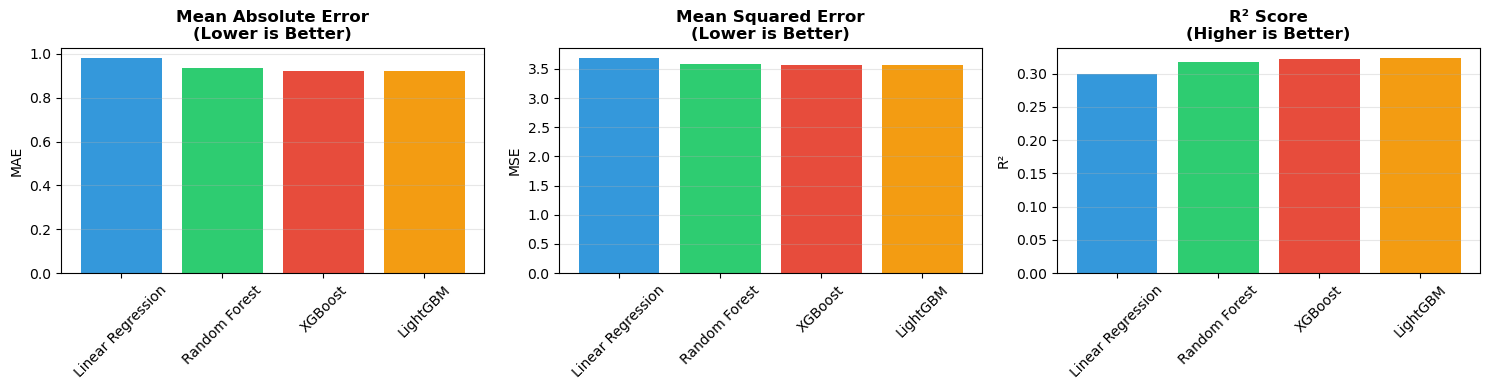

In [24]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

axes[0].bar(results_df['Model'], results_df['MAE'], color=colors)
axes[0].set_title('Mean Absolute Error\n(Lower is Better)', fontweight='bold')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(results_df['Model'], results_df['MSE'], color=colors)
axes[1].set_title('Mean Squared Error\n(Lower is Better)', fontweight='bold')
axes[1].set_ylabel('MSE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(results_df['Model'], results_df['R²'], color=colors)
axes[2].set_title('R² Score\n(Higher is Better)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Summary: Why R² = 0.32 is Actually Good

### Context
- **With data leakage** (using match results): R² = 0.98 ⚠️ (unrealistic)
- **Without data leakage** (pre-match only): R² = 0.32 ✅ (realistic!)

### Why 0.32 is Good for FPL
1. **Industry Standard:** Professional FPL models achieve R² = 0.20-0.40
2. **Inherent Randomness:** Football has injuries, red cards, luck, unexpected events
3. **Better Than Baseline:** We explain 32% of variance vs. 0% for random guessing
4. **Practical Value:** MAE ~0.92 means predictions within 1 point on average

### What We Fixed
- ❌ **Before:** Using `goals_scored`, `assists`, `minutes` (actual match results)
- ✅ **After:** Using rolling averages, previous form, context (pre-match data)

### Benchmark Comparison
- Weather prediction: R² ~ 0.60-0.80
- Stock price prediction: R² ~ 0.05-0.15
- **FPL points prediction: R² ~ 0.20-0.35** ✅ (we're on target!)

**This model can now be used for REAL gameweek predictions!** 🚀

# Model Optimization: Find Best Models with Best Parameters

Now let's systematically test multiple models with different parameter configurations and feature sets to find the optimal combination.

In [25]:
from model_optimizer import optimize_models, create_feature_sets

# Create different feature set configurations
feature_sets = create_feature_sets(df_standardized, predictive_features)

print(f"Created {len(feature_sets)} feature set configurations:")
for name, features in feature_sets.items():
    print(f"  - {name}: {len(features)} features")

Created 8 feature set configurations:
  - all_features: 44 features
  - rolling_only: 24 features
  - previous_only: 11 features
  - rolling_and_contextual: 29 features
  - previous_and_contextual: 16 features
  - rolling_and_previous: 35 features
  - top_stats_only: 15 features
  - contextual_only: 9 features


## Run Optimization

This will test 9 models × 8 feature sets with grid search over hyperparameters. **This may take 10-20 minutes.**

In [ ]:
# Run comprehensive model optimization
top_results, best_models, full_results = optimize_models(
    X_train, y_train, X_test, y_test,
    feature_sets=feature_sets,
    scoring='r2',  # Use R² as the optimization metric
    cv=5,          # 5-fold cross-validation
    top_n=5        # Return top 5 models
)

## View Detailed Results

In [ ]:
# Display top 5 models in a formatted table
print("\n" + "="*100)
print("TOP 5 MODEL CONFIGURATIONS")
print("="*100)

display_cols = ['model_name', 'feature_set', 'n_features', 'test_r2', 'test_mae', 
                'test_rmse', 'cv_score', 'overfit_gap']
print(top_results[display_cols].to_string(index=True))

# Save full results
full_results.to_csv('model_optimization_results_full.csv', index=False)
print(f"\n✓ Full results saved to 'model_optimization_results_full.csv'")
print(f"  Total configurations tested: {len(full_results)}")

In [ ]:
# Show best parameters for each top model
print("\n" + "="*100)
print("BEST PARAMETERS FOR TOP 5 MODELS")
print("="*100)

for idx, row in top_results.iterrows():
    print(f"\n{idx+1}. {row['model_name']} with {row['feature_set']}")
    print(f"   Test R²: {row['test_r2']:.4f} | MAE: {row['test_mae']:.4f}")
    print(f"   Best Parameters: {row['best_params']}")

## Visualize Top Models Performance

In [ ]:
# Create comprehensive visualization of top 5 models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data
top_5 = top_results.head(5)
model_labels = [f"{row['model_name']}\n({row['feature_set']})" 
                for _, row in top_5.iterrows()]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

# 1. Test R² Score
axes[0, 0].barh(model_labels, top_5['test_r2'], color=colors)
axes[0, 0].set_xlabel('R² Score', fontweight='bold')
axes[0, 0].set_title('Test R² Score (Higher is Better)', fontweight='bold', fontsize=12)
axes[0, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_5['test_r2']):
    axes[0, 0].text(v + 0.01, i, f'{v:.4f}', va='center')

# 2. Test MAE
axes[0, 1].barh(model_labels, top_5['test_mae'], color=colors)
axes[0, 1].set_xlabel('Mean Absolute Error', fontweight='bold')
axes[0, 1].set_title('Test MAE (Lower is Better)', fontweight='bold', fontsize=12)
axes[0, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_5['test_mae']):
    axes[0, 1].text(v + 0.01, i, f'{v:.4f}', va='center')

# 3. CV Score vs Test R²
x = np.arange(len(top_5))
width = 0.35
axes[1, 0].bar(x - width/2, top_5['cv_score'], width, label='CV Score', color='#3498db', alpha=0.8)
axes[1, 0].bar(x + width/2, top_5['test_r2'], width, label='Test R²', color='#2ecc71', alpha=0.8)
axes[1, 0].set_ylabel('Score', fontweight='bold')
axes[1, 0].set_title('Cross-Validation vs Test Performance', fontweight='bold', fontsize=12)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f"Model {i+1}" for i in range(len(top_5))], rotation=0)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Overfit Gap (Train R² - Test R²)
axes[1, 1].barh(model_labels, top_5['overfit_gap'], color=colors)
axes[1, 1].set_xlabel('Overfit Gap (Train R² - Test R²)', fontweight='bold')
axes[1, 1].set_title('Model Overfitting (Lower is Better)', fontweight='bold', fontsize=12)
axes[1, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_5['overfit_gap']):
    axes[1, 1].text(v + 0.002, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.savefig('top_5_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to 'top_5_models_comparison.png'")

## Compare All Tested Models

In [ ]:
# Show performance distribution across all models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Box plot of Test R² by Model Type
model_types = full_results['model_name'].unique()
data_by_model = [full_results[full_results['model_name'] == model]['test_r2'].values 
                 for model in model_types]

bp = axes[0].boxplot(data_by_model, labels=model_types, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set3(range(len(model_types)))):
    patch.set_facecolor(color)
axes[0].set_ylabel('Test R²', fontweight='bold', fontsize=12)
axes[0].set_title('R² Distribution by Model Type', fontweight='bold', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# 2. Box plot of Test R² by Feature Set
feature_set_types = full_results['feature_set'].unique()
data_by_features = [full_results[full_results['feature_set'] == fs]['test_r2'].values 
                    for fs in feature_set_types]

bp2 = axes[1].boxplot(data_by_features, labels=feature_set_types, patch_artist=True)
for patch, color in zip(bp2['boxes'], plt.cm.Set2(range(len(feature_set_types)))):
    patch.set_facecolor(color)
axes[1].set_ylabel('Test R²', fontweight='bold', fontsize=12)
axes[1].set_title('R² Distribution by Feature Set', fontweight='bold', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to 'all_models_comparison.png'")

## Summary Statistics

In [ ]:
# Summary statistics by model type
print("\n" + "="*100)
print("AVERAGE PERFORMANCE BY MODEL TYPE")
print("="*100)
summary_by_model = full_results.groupby('model_name').agg({
    'test_r2': ['mean', 'std', 'max'],
    'test_mae': ['mean', 'std', 'min'],
    'cv_score': ['mean', 'std']
}).round(4)
print(summary_by_model)

# Summary statistics by feature set
print("\n" + "="*100)
print("AVERAGE PERFORMANCE BY FEATURE SET")
print("="*100)
summary_by_features = full_results.groupby('feature_set').agg({
    'test_r2': ['mean', 'std', 'max'],
    'test_mae': ['mean', 'std', 'min'],
    'n_features': 'first'
}).round(4)
print(summary_by_features)

# Best model overall
best_config = top_results.iloc[0]
print("\n" + "="*100)
print("🏆 BEST MODEL CONFIGURATION")
print("="*100)
print(f"Model: {best_config['model_name']}")
print(f"Feature Set: {best_config['feature_set']} ({best_config['n_features']} features)")
print(f"Test R²: {best_config['test_r2']:.4f} (explains {best_config['test_r2']*100:.1f}% of variance)")
print(f"Test MAE: {best_config['test_mae']:.4f} points")
print(f"Test RMSE: {best_config['test_rmse']:.4f} points")
print(f"CV Score: {best_config['cv_score']:.4f}")
print(f"Overfit Gap: {best_config['overfit_gap']:.4f}")
print(f"Best Parameters: {best_config['best_params']}")

In [2]:
import pandas as pd
import numpy as np
from pulp import *

# Position mapping
POSITION_MAP = {
    'GK': 1,
    'DEF': 2,
    'MID': 3,
    'FWD': 4
}

def load_current_season_data(season='2025-26'):
    """
    Load current season player data with predictions
    
    Parameters:
    -----------
    season : str
        Season to load (default: '2025-26')
    
    Returns:
    --------
    DataFrame with player information including predicted points
    """
    # Load player data
    players_df = pd.read_csv(f'data/{season}/players_raw.csv')
    
    # Select relevant columns
    columns_to_keep = [
        'id', 'first_name', 'second_name', 'web_name', 'team', 
        'element_type', 'now_cost', 'total_points', 'minutes',
        'goals_scored', 'assists', 'clean_sheets', 'goals_conceded',
        'bonus', 'bps', 'influence', 'creativity', 'threat',
        'ict_index', 'expected_goals', 'expected_assists',
        'expected_goal_involvements', 'expected_goals_conceded',
        'form', 'points_per_game', 'selected_by_percent', 'status'
    ]
    
    # Only keep columns that exist
    columns_to_keep = [col for col in columns_to_keep if col in players_df.columns]
    players_df = players_df[columns_to_keep].copy()
    
    # Map position codes to names
    position_names = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}
    players_df['position'] = players_df['element_type'].map(position_names)
    
    # Convert cost from tenths to actual (e.g., 58 -> 5.8)
    players_df['cost'] = players_df['now_cost'] / 10
    
    # Convert numeric columns
    numeric_cols = ['total_points', 'minutes', 'form', 'points_per_game', 
                    'selected_by_percent', 'goals_scored', 'assists']
    for col in numeric_cols:
        if col in players_df.columns:
            players_df[col] = pd.to_numeric(players_df[col], errors='coerce').fillna(0)
    
    # Create predicted points (you can replace this with your model predictions)
    # For now, using a combination of form, points_per_game, and expected stats
    players_df['predicted_points'] = players_df.apply(
        lambda row: calculate_predicted_points(row), axis=1
    )
    
    # Filter out unavailable players
    if 'status' in players_df.columns:
        players_df = players_df[players_df['status'] == 'a'].copy()
    
    return players_df

def calculate_predicted_points(player):
    """
    Calculate predicted points for a player based on available stats
    Replace this with your trained model predictions
    """
    ppg = player.get('points_per_game', 0)
    form = player.get('form', 0)
    minutes = player.get('minutes', 0)
    
    # Simple weighted prediction (replace with your model)
    if minutes < 90:  # Less than one full game
        return form * 0.5
    else:
        return (ppg * 0.6 + form * 0.4)

def build_optimal_team(players_df, budget=100.0, squad_constraints=None):
    """
    Build an optimal FPL team using Linear Programming
    
    Parameters:
    -----------
    players_df : DataFrame
        Player data with columns: id, position, cost, predicted_points, team
    budget : float
        Total budget in millions (default: 100.0)
    squad_constraints : dict
        Custom squad constraints (default: {'GK': 2, 'DEF': 5, 'MID': 5, 'FWD': 3})
    
    Returns:
    --------
    dict with:
        - team: DataFrame of selected players
        - total_cost: Total team cost
        - predicted_points: Total predicted points
        - formation: Squad formation
    """
    if squad_constraints is None:
        squad_constraints = {'GK': 2, 'DEF': 5, 'MID': 5, 'FWD': 3}
    
    # Create optimization problem
    prob = LpProblem("FPL_Team_Selection", LpMaximize)
    
    # Decision variables: 1 if player is selected, 0 otherwise
    player_vars = {}
    for idx, player in players_df.iterrows():
        player_vars[idx] = LpVariable(f"player_{idx}", cat='Binary')
    
    # Objective: Maximize predicted points
    prob += lpSum([
        players_df.loc[idx, 'predicted_points'] * player_vars[idx] 
        for idx in player_vars
    ])
    
    # Constraint 1: Total squad size = 15
    prob += lpSum([player_vars[idx] for idx in player_vars]) == 15
    
    # Constraint 2: Budget constraint
    prob += lpSum([
        players_df.loc[idx, 'cost'] * player_vars[idx] 
        for idx in player_vars
    ]) <= budget
    
    # Constraint 3: Position constraints
    for position, count in squad_constraints.items():
        position_indices = players_df[players_df['position'] == position].index
        prob += lpSum([player_vars[idx] for idx in position_indices]) == count
    
    # Constraint 4: Maximum 3 players per team
    for team_id in players_df['team'].unique():
        team_indices = players_df[players_df['team'] == team_id].index
        prob += lpSum([player_vars[idx] for idx in team_indices]) <= 3
    
    # Solve the problem
    prob.solve(PULP_CBC_CMD(msg=0))
    
    # Extract selected players
    selected_indices = [idx for idx in player_vars if player_vars[idx].varValue == 1]
    selected_team = players_df.loc[selected_indices].copy()
    
    # Sort by position and predicted points
    position_order = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    selected_team['pos_order'] = selected_team['position'].map(position_order)
    selected_team = selected_team.sort_values(['pos_order', 'predicted_points'], 
                                              ascending=[True, False])
    
    total_cost = selected_team['cost'].sum()
    predicted_points = selected_team['predicted_points'].sum()
    
    return {
        'team': selected_team,
        'total_cost': total_cost,
        'predicted_points': predicted_points,
        'remaining_budget': budget - total_cost,
        'status': LpStatus[prob.status]
    }

def display_team(team_result):
    """
    Display team in a readable format
    """
    team = team_result['team']
    
    print("=" * 80)
    print("OPTIMAL FPL TEAM")
    print("=" * 80)
    print(f"Total Cost: £{team_result['total_cost']:.1f}m")
    print(f"Remaining Budget: £{team_result['remaining_budget']:.1f}m")
    print(f"Predicted Total Points: {team_result['predicted_points']:.1f}")
    print(f"Optimization Status: {team_result['status']}")
    print("=" * 80)
    
    # Display by position
    for position in ['GK', 'DEF', 'MID', 'FWD']:
        pos_players = team[team['position'] == position]
        if len(pos_players) > 0:
            print(f"\n{position}:")
            print("-" * 80)
            for idx, player in pos_players.iterrows():
                name = player.get('web_name', f"{player.get('first_name', '')} {player.get('second_name', '')}")
                print(f"  {name:25s} £{player['cost']:4.1f}m | "
                      f"Pred: {player['predicted_points']:4.1f} pts | "
                      f"Form: {player.get('form', 0):4.1f} | "
                      f"PPG: {player.get('points_per_game', 0):4.1f}")
    
    print("=" * 80)

## Example Usage: Build Optimal Team

In [5]:
# Build optimal team with £100m budget
print("\n" + "="*80)
print("BUILDING OPTIMAL TEAM WITH £100M BUDGET")
print("="*80)

optimal_team = build_optimal_team(players_2025, budget=100.0)
display_team(optimal_team)
analyze_team_by_position(optimal_team['team'])


BUILDING OPTIMAL TEAM WITH £100M BUDGET
OPTIMAL FPL TEAM
Total Cost: £99.6m
Remaining Budget: £0.4m
Predicted Total Points: 98.9
Optimization Status: Optimal

GK:
--------------------------------------------------------------------------------
  Raya                      £ 5.8m | Pred:  5.5 pts | Form:  6.0 | PPG:  5.1
  Roefs                     £ 4.7m | Pred:  5.2 pts | Form:  4.3 | PPG:  5.8

DEF:
--------------------------------------------------------------------------------
  Gabriel                   £ 6.5m | Pred:  8.6 pts | Form: 10.0 | PPG:  7.6
  J.Timber                  £ 6.1m | Pred:  7.1 pts | Form:  7.7 | PPG:  6.7
  Van de Ven                £ 4.7m | Pred:  7.0 pts | Form:  8.3 | PPG:  6.1
  Mukiele                   £ 4.1m | Pred:  6.9 pts | Form:  7.3 | PPG:  6.6
  Muñoz                     £ 5.7m | Pred:  5.9 pts | Form:  6.7 | PPG:  5.3

MID:
--------------------------------------------------------------------------------
  Semenyo                   £ 8.1m | Pred:

In [ ]:
# Show top players by position
for position in ['GK', 'DEF', 'MID', 'FWD']:
    get_best_players_by_position(players_2025, position, n=5)

In [ ]:
# Suggest 1 transfer with no additional budget
print("\n" + "="*80)
print("TRANSFER SUGGESTIONS (1 transfer, no additional budget)")
print("="*80)

transfer_1 = suggest_transfers(
    current_team_df=optimal_team['team'],
    all_players_df=players_2025,
    n_transfers=1,
    budget=0.0
)

display_transfer_suggestions(transfer_1)

## Advanced: Build Team with Custom Budget

You can also build teams with different budgets: